#  MedAssist-AI-IMAGE : Análisis Visual de Imágenes de Medicamentos
---

## PREPROCESAMIENTO Y CONSTRUCCIÓN DEL DATASET

### Creación del dataset

El dataset se construyó a partir de dos fuentes principales:

- **Un JSON de medicamentos del CIMA**, que contiene información estructurada de cada medicamento.
- **Imagenes obtenidas del JSON**, en la que se almacenan imágenes asociadas a cada medicamento.

El objetivo de esta fase fue generar un **dataset unificado**, donde cada fila representara **una imagen individual** y estuviera vinculada a los metadatos farmacológicos del medicamento correspondiente. De esta forma, el resultado final es una base de datos preparada para realizar análisis exploratorio y tareas de clasificación.

### Proceso de construcción

La construcción del dataset siguió los siguientes pasos:

1. **Lectura del JSON de medicamentos**  
   Se procesó el archivo JSON para extraer la información relevante de cada medicamento: nombre, número de registro, principio activo, clasificación ATC, forma farmacéutica, vía de administración, laboratorio, información de receta, carácter genérico, etc.

2. **Indexación de imágenes locales**  
   Se recorrió la carpeta de imágenes para localizar todos los archivos válidos (`.jpg`, `.jpeg`, `.png`, `.webp`, `.bmp`, `.tif`, `.tiff`) y organizarlos de forma que pudieran relacionarse con cada medicamento.

3. **Emparejamiento entre medicamento e imagen**  
   La relación entre los registros del JSON y las imágenes locales se realizó utilizando principalmente el **número de registro (`nregistro`)** y el **tipo de imagen** detectado en el nombre del archivo.  
   Esto permitió asociar correctamente cada imagen con su medicamento correspondiente.

4. **Normalización del tipo de imagen**  
   En el JSON y en los nombres de archivo aparecían tipos de imagen técnicos como:
   - `materialas`
   - `formafarmac`

   Para facilitar la interpretación, estos tipos se transformaron en categorías más claras:
   - `materialas` → `caja`
   - `formafarmac` → `pastilla`

5. **Extracción y limpieza de metadatos**  
   Se normalizaron distintos campos textuales para mejorar la consistencia del dataset:
   - nombres de medicamentos,
   - principios activos,
   - textos con tildes o símbolos,
   - campos con posibles listas o estructuras anidadas.

6. **Construcción de la etiqueta terapéutica**  
   A partir de la clasificación ATC de cada medicamento, se derivó una variable de mayor nivel llamada **`macroclase_15_nombre`**, que agrupa los medicamentos en grandes categorías terapéuticas generales.  
   Esta variable se definió como la **etiqueta principal de clasificación**, ya que ofrece un equilibrio razonable entre interpretabilidad clínica y viabilidad del modelado.

7. **Generación del CSV final**  
   El resultado de este proceso fue un CSV principal en el que:
   - **cada fila representa una imagen**,  
   - **cada imagen mantiene la ruta al archivo**,  
   - y **cada fila incluye las etiquetas y metadatos del medicamento asociado**.

### Estructura del dataset resultante

Entre las variables más importantes del dataset generado se encuentran:

- **Identificación de la muestra**
  - `sample_id`
  - `image_path`
  - `image_filename`

- **Información visual**
  - `image_type_raw`
  - `image_type`

- **Identificación del medicamento**
  - `nregistro`
  - `nombre`
  - `nombre_normalizado`

- **Información farmacológica**
  - `principio_activo_texto`
  - `principio_activo_normalizado`
  - `num_principios_activos`
  - `atc1_codigo`
  - `atc2_codigo`
  - `atc3_codigo`
  - `atc3_nombre`
  - `atc4_codigo`
  - `atc4_nombre`
  - `atc5_codigo`
  - `atc5_nombre`

- **Etiqueta terapéutica principal**
  - `macroclase_15_codigo`
  - `macroclase_15_nombre`

- **Otras variables de apoyo**
  - `dosis`
  - `forma_farmaceutica`
  - `forma_farmaceutica_simplificada`
  - `via_administracion`
  - `labtitular`
  - `labcomercializador`
  - `cpresc`
  - `receta`
  - `generico`
  - `comerc`

### Archivos auxiliares generados

Además del CSV principal, se generaron varios archivos auxiliares para facilitar el análisis exploratorio y la definición de experimentos:

- distribuciones por clase terapéutica,
- distribuciones por nivel ATC,
- distribuciones por principio activo y nombre normalizado,
- subconjuntos específicos como:
  - `dataset_caja.csv`
  - `dataset_pastilla.csv`
  - `dataset_nombre_frecuente.csv`

También se generó un archivo de resumen con estadísticas globales del dataset.


### Aspectos metodológicos tenidos en cuenta durante la construcción

Durante la creación del dataset se tuvieron en cuenta varios criterios importantes para asegurar que la base de datos fuera útil, consistente y adecuada para el posterior EDA y modelado:

1. Una fila por imagen
Se decidió que la unidad de análisis fuera la **imagen individual**, no el medicamento. Esto es fundamental porque la tarea posterior es una **clasificación de imágenes**.

2. Trazabilidad entre imagen y medicamento
Cada imagen conserva la referencia al medicamento del que procede mediante `nregistro`, lo que permite analizar tanto la dimensión visual como la farmacológica.

3. Evitar duplicados exactos
Cuando una misma imagen aparecía repetida dentro del mismo medicamento, se evitó incluirla varias veces para no introducir sesgos artificiales.

4. Uso de etiquetas interpretables
Aunque el dataset conserva niveles ATC más específicos, se eligió `macroclase_15_nombre` como referencia principal porque representa un nivel terapéutico general más interpretable y manejable para una primera tarea de clasificación.

5. Limpieza y normalización de texto
Se aplicaron procesos de normalización para reducir ruido en campos clave como nombre del medicamento o principio activo, mejorando así la calidad del dataset.

6. Flexibilidad para distintos niveles de clasificación
El dataset no solo permite trabajar con una etiqueta general (`macroclase_15_nombre`), sino también con etiquetas más específicas (`atc3_nombre`, `atc5_nombre`, `principio_activo_normalizado`, etc.), lo que facilita futuros experimentos.

---

## Análisis Exploratorio de Datos (EDA)

### Motivación y objetivo del EDA

Este notebook realiza un análisis exploratorio del dataset de imágenes de medicamentos españoles (AEMPS), centrado en la clasificación por grupos terapéuticos (`macroclase_15_nombre`). La tarea consiste en clasificar imágenes de medicamentos —tanto fotos del producto físico (`pastilla`) como del envase (`caja`)— en categorías terapéuticas.

### Diseño de clases

En lugar de trabajar con las 15 macroclases originales, se adopta un enfoque más manejable y justificado: se seleccionan **4 clases principales** con suficiente representación en el dataset, y el resto de medicamentos se agrupan en una clase `otros`. Este diseño responde a dos objetivos:

1. Garantizar que todas las clases tienen suficiente volumen de datos para entrenar modelos de forma fiable.
2. Evaluar cómo se comporta el modelo con una clase heterogénea (`otros`), lo que refleja un escenario realista donde no todos los medicamentos encajan limpiamente en las categorías principales.

El EDA está estructurado en tres bloques:
- **Bloque 1 (secciones 1–4)**: descripción general del dataset y definición de las 5 clases.
- **Bloque 2 (secciones 5–9)**: análisis visual profundo de cada clase (mosaicos, propiedades de imagen, color, brillo, contraste).
- **Bloque 3 (secciones 10–12)**: análisis del desequilibrio, estrategia de data augmentation y conclusiones.

## 0. Dependencias y configuración

In [22]:
import warnings, random, os
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image, ImageEnhance
import cv2
from scipy.stats import entropy
from pathlib import Path
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})
sns.set_style('whitegrid')

TARGET = 'macroclase_15_nombre'

# Paleta fija por clase final 
COLOR_TIPO = {'caja': '#4C72B0', 'pastilla': '#DD8452'}

## 1. Carga del dataset y descripción general

Cargamos el CSV generado por `build_medicines_dataset_2.py`. Cada fila es una imagen con sus metadatos asociados: tipo de imagen, macroclase terapéutica, forma farmacéutica, vía de administración y laboratorio, entre otros. El primer paso es tener una visión global del tamaño y estructura del dataset antes de aplicar cualquier filtro.

In [3]:
CSV_PATH = 'output/dataset.csv'  

df = pd.read_csv(
    CSV_PATH,
    dtype={'nregistro': str, 'atc1_codigo': str, 'atc2_codigo': str,
           'atc3_codigo': str, 'atc4_codigo': str, 'atc5_codigo': str},
    true_values=['True', 'true', '1'],
    false_values=['False', 'false', '0'],
)

print('=' * 55)
print('DESCRIPCIÓN GENERAL DEL DATASET')
print('=' * 55)
print(f'Total de imágenes:          {len(df):>8,}')
print(f'Medicamentos únicos:        {df["nregistro"].nunique():>8,}')
print(f'Imágenes de caja:           {(df["image_type"]=="caja").sum():>8,}')
print(f'Imágenes de pastilla:       {(df["image_type"]=="pastilla").sum():>8,}')
print(f'Con macroclase asignada:    {df[TARGET].notna().sum():>8,}  ({df[TARGET].notna().mean()*100:.1f}%)')
print(f'Sin macroclase asignada:    {df[TARGET].isna().sum():>8,}  ({df[TARGET].isna().mean()*100:.1f}%)')
print(f'Macroclases únicas:         {df[TARGET].nunique():>8}')
print('=' * 55)
print()
print('Distribución por macroclase (completa):')
print(df[TARGET].value_counts(dropna=False).to_string())
df.head(3)

  DESCRIPCIÓN GENERAL DEL DATASET
  Total de imágenes:             9,998
  Medicamentos únicos:           5,021
  Imágenes de caja:              5,021
  Imágenes de pastilla:          4,977
  Con macroclase asignada:       9,998  (100.0%)
  Sin macroclase asignada:           0  (0.0%)
  Macroclases únicas:               15

Distribución por macroclase (completa):
macroclase_15_nombre
Cardiovascular                              1807
Neurología y psiquiatría                    1601
Antiinfecciosos sistémicos                   805
Respiratorio                                 763
Dolor y anestesia                            684
Genitourinario y hormonas sexuales           617
Hematología y sangre                         586
Oncología                                    558
Inmunología y biológicos                     494
Musculoesquelético                           481
Metabolismo, diabetes y nutrición            426
Digestivo                                    374
Hormonal sistémico y vari

,sample_id,image_path,image_filename,image_type_raw,image_type,nregistro,nombre,nombre_normalizado,principio_activo_texto,principio_activo_normalizado,...,dosis,forma_farmaceutica,forma_farmaceutica_simplificada,via_administracion,labtitular,labcomercializador,cpresc,receta,generico,comerc
0,42991_caja_1,/Users/merybri/Library/CloudStorage/OneDrive-U...,a_a_s_100_mg_comprimidos__42991__materialas__0...,materialas,caja,42991,A.A.S. 100 mg COMPRIMIDOS,a a s 100 mg comprimidos,ACETILSALICILICO ACIDO,acetilsalicilico acido,...,100 mg,COMPRIMIDO,COMPRIMIDO,VÍA ORAL,Laboratorio Stada S.L.,Laboratorio Stada S.L.,Medicamento Sujeto A Prescripción Médica. Trat...,True,False,True
1,42991_pastilla_1,/Users/merybri/Library/CloudStorage/OneDrive-U...,a_a_s_100_mg_comprimidos__42991__formafarmac__...,formafarmac,pastilla,42991,A.A.S. 100 mg COMPRIMIDOS,a a s 100 mg comprimidos,ACETILSALICILICO ACIDO,acetilsalicilico acido,...,100 mg,COMPRIMIDO,COMPRIMIDO,VÍA ORAL,Laboratorio Stada S.L.,Laboratorio Stada S.L.,Medicamento Sujeto A Prescripción Médica. Trat...,True,False,True
2,42956_caja_1,/Users/merybri/Library/CloudStorage/OneDrive-U...,a_a_s_500_mg_comprimidos__42956__materialas__0...,materialas,caja,42956,A.A.S. 500 mg COMPRIMIDOS,a a s 500 mg comprimidos,ACETILSALICILICO ACIDO,acetilsalicilico acido,...,500 mg,COMPRIMIDO,COMPRIMIDO,VÍA ORAL,Laboratorio Stada S.L.,Laboratorio Stada S.L.,Sin Receta,False,False,True


## 2. Definición de las 5 clases de trabajo

### Criterio de selección

Se seleccionan las **4 macroclases con mayor número de imágenes** como clases principales. El resto se agrupan en la clase otros. Este criterio garantiza que cada clase principal tiene suficiente volumen para entrenar y evaluar modelos de forma fiable, especialmente en la etapa de Deep Learning donde modelos como ResNet o EfficientNet necesitan varios cientos de ejemplos por clase para ajustar sus capas finales mediante fine-tuning.

La clase otros tiene un papel especial en el proyecto: es intencionalmente heterogénea, ya que agrupa categorías terapéuticas muy distintas. Esto permite evaluar si el modelo es capaz de identificar cuándo una imagen no pertenece a ninguna de las clases principales, lo que es relevante en un escenario de despliegue real donde pueden llegar medicamentos de cualquier categoría.

Las 5 clases seleccionadas (4 macroclases y otros) definen el problema de clasificación multiclase que se abordará en ML y DL.

In [4]:
# Filtrar a imágenes con macroclase conocida
df = df[df[TARGET].notna()].copy().reset_index(drop=True)

# Seleccionar las 4 clases más frecuentes
conteos_orig = df[TARGET].value_counts()
TOP4 = conteos_orig.head(4).index.tolist()

print('4 clases principales seleccionadas (por volumen):')
for i, cls in enumerate(TOP4, 1):
    print(f'  {i}. {cls}: {conteos_orig[cls]:,} imágenes ({conteos_orig[cls]/len(df)*100:.1f}%)')

# Crear columna de clase final
df['clase'] = df[TARGET].apply(lambda x: x if x in TOP4 else 'otros')

# Paleta de colores fija por clase 
CLASES = TOP4 + ['otros']
PALETTE = dict(zip(CLASES, ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']))

print('\nDistribución de las 5 clases de trabajo:')
conteos = df['clase'].value_counts().reindex(CLASES)
for cls, n in conteos.items():
    barra = '█' * int(n / conteos.max() * 30)
    print(f'  {cls:<45} {n:>6,}  {barra}')

print(f'\nTotal imágenes de trabajo: {len(df):,}')

4 clases principales seleccionadas (por volumen):
  1. Cardiovascular: 1,807 imágenes (18.1%)
  2. Neurología y psiquiatría: 1,601 imágenes (16.0%)
  3. Antiinfecciosos sistémicos: 805 imágenes (8.1%)
  4. Respiratorio: 763 imágenes (7.6%)

Distribución de las 5 clases de trabajo:
  Cardiovascular                                 1,807  ██████████
  Neurología y psiquiatría                       1,601  █████████
  Antiinfecciosos sistémicos                       805  ████
  Respiratorio                                     763  ████
  otros                                          5,022  ██████████████████████████████

Total imágenes de trabajo: 9,998


## 3. Distribución de las 5 clases

Visualizamos la distribución de las 5 clases de trabajo. Este gráfico es el punto de partida para entender el desequilibrio del dataset, que se analizará en profundidad en la sección 10. También mostramos cómo se reparten las imágenes de caja y pastilla dentro de cada clase, ya que un modelo podría entrenarse con un tipo o con ambos.

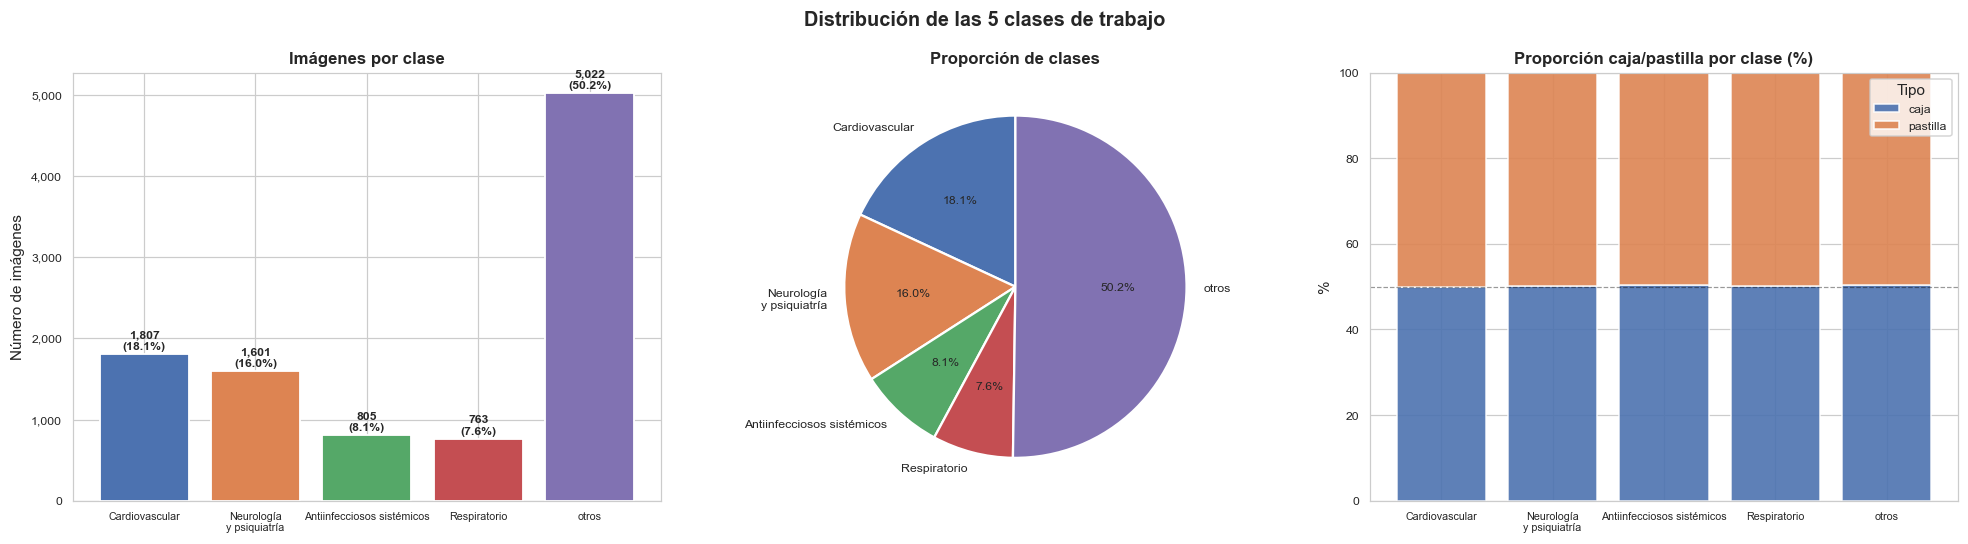

Ratio de desequilibrio (max/min): 6.6x


In [5]:
conteos = df['clase'].value_counts().reindex(CLASES)
total   = len(df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Barplot de clases 
bars = axes[0].bar(CLASES, conteos.values,
                   color=[PALETTE[c] for c in CLASES],
                   edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, conteos.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.003,
                 f'{val:,}\n({val/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_title('Imágenes por clase', fontweight='bold')
axes[0].set_ylabel('Número de imágenes')
axes[0].set_xticklabels(
    [c.replace(' y ', '\ny ').replace(', ', ',\n') for c in CLASES],
    fontsize=7
)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie 
axes[1].pie(conteos.values, labels=[c.replace(' y ', '\ny ') for c in CLASES],
            autopct='%1.1f%%',
            colors=[PALETTE[c] for c in CLASES],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
            textprops={'fontsize': 8})
axes[1].set_title('Proporción de clases', fontweight='bold')

#Caja vs pastilla por clase
pivot = df.groupby(['clase', 'image_type']).size().unstack(fill_value=0).reindex(CLASES)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(CLASES))
for tipo, color in COLOR_TIPO.items():
    if tipo in pivot_pct.columns:
        axes[2].bar(CLASES, pivot_pct[tipo].values, bottom=bottom,
                    color=color, edgecolor='white', label=tipo, alpha=0.9)
        bottom += pivot_pct[tipo].fillna(0).values
axes[2].axhline(50, color='black', linestyle='--', linewidth=0.8, alpha=0.4)
axes[2].set_title('Proporción caja/pastilla por clase (%)', fontweight='bold')
axes[2].set_ylabel('%')
axes[2].set_ylim(0, 100)
axes[2].set_xticklabels(
    [c.replace(' y ', '\ny ').replace(', ', ',\n') for c in CLASES],
    fontsize=7
)
axes[2].legend(title='Tipo', fontsize=8)

plt.suptitle('Distribución de las 5 clases de trabajo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribucion_clases.png', bbox_inches='tight')
plt.show()

ratio = conteos.max() / conteos.min()
print(f'Ratio de desequilibrio (max/min): {ratio:.1f}x')

El análisis de la distribución de clases muestra un desequilibrio notable en el dataset. La clase otros concentra aproximadamente la mitad de las imágenes, mientras que las clases restantes presentan porcentajes bastante menores, especialmente antiinfecciosos sistémicos y respiratorio. Este comportamiento indica que el problema de clasificación no parte de una distribución homogénea, por lo que será necesario tener en cuenta este desbalance en fases posteriores de modelado y evaluación.

No obstante, la proporción entre imágenes de caja y pastilla se mantiene prácticamente constante entre clases, lo que resulta positivo desde el punto de vista metodológico, ya que reduce el riesgo de que el modelo aprenda asociaciones falsas entre la clase terapéutica y el tipo de imagen.

## 4. Propiedades físicas de las imágenes: tamaño y resolución

Antes de analizar el contenido visual, es necesario conocer las propiedades físicas de las imágenes: sus dimensiones (ancho × alto), su resolución y el tamaño. Esta información es relevante porque:

- Si las imágenes tienen resoluciones heterogéneas, se necesitará hacer un resize antes de cualquier modelo.
- Si hay imágenes muy pequeñas, pueden haberse degradado en la descarga o ser de baja calidad.
- El tamaño de resize que se elija para el modelo (224×224, 299×299, etc.) debe ser adecuado para la resolución típica del dataset.

Se analiza sobre una muestra estratificada por clase para obtener estadísticas representativas sin tener que leer todas las imágenes del disco.

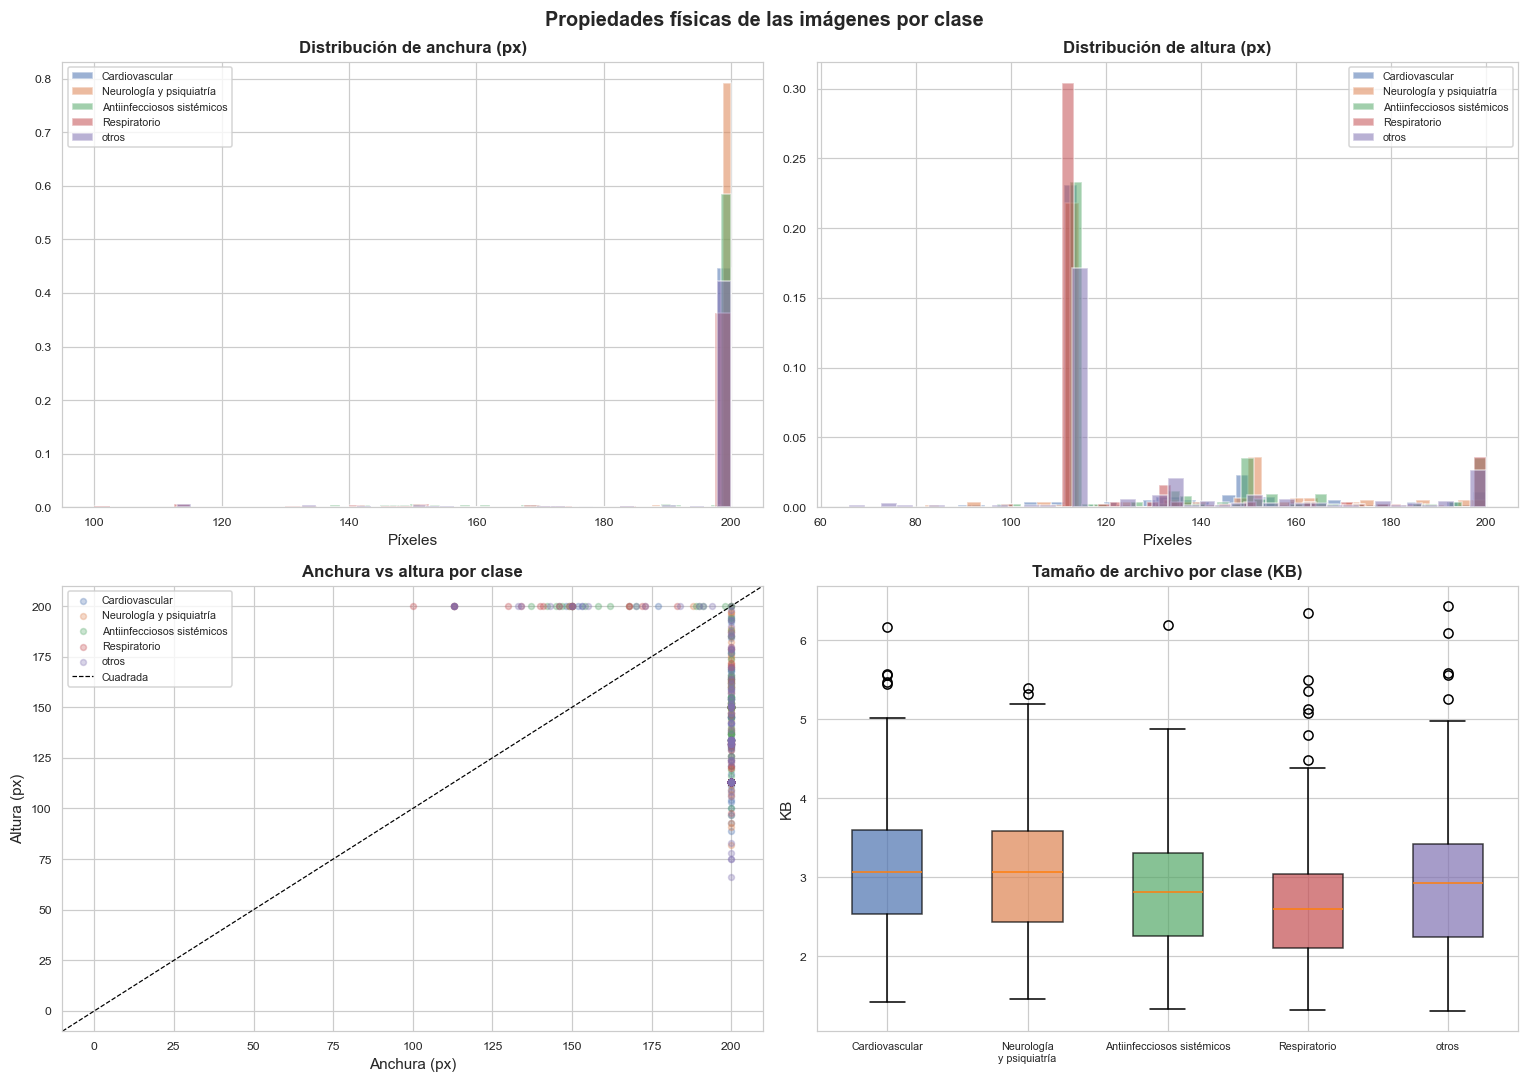

Estadísticas de resolución por clase:
                            width                                                 height                                                size_kb                                   
                            count   mean   std    min    25%    50%    75%    max  count   mean   std   min    25%    50%    75%    max   count mean  std  min  25%  50%  75%  max
clase                                                                                                                                                                             
Antiinfecciosos sistémicos  200.0  197.0  12.0  137.0  200.0  200.0  200.0  200.0  200.0  132.0  29.0  97.0  113.0  113.0  150.0  200.0   200.0  3.0  1.0  1.0  2.0  3.0  3.0  6.0
Cardiovascular              200.0  198.0   9.0  113.0  200.0  200.0  200.0  200.0  200.0  126.0  24.0  89.0  113.0  113.0  136.0  200.0   200.0  3.0  1.0  1.0  3.0  3.0  4.0  6.0
Neurología y psiquiatría    199.0  200.0   4.0  150.0  200.0  200.0

In [6]:
N_MUESTRA_PROPS = 200   # imágenes por clase para analizar propiedades

def get_img_properties(path):
    """Lee una imagen y devuelve sus propiedades físicas."""
    try:
        img = Image.open(path)
        w, h = img.size
        size_kb = Path(path).stat().st_size / 1024
        return {'width': w, 'height': h, 'aspect': w/h, 'size_kb': size_kb}
    except Exception:
        return None

# Muestra estratificada
muestra_props = (
    df.groupby('clase', group_keys=False)
    .apply(lambda x: x.sample(min(N_MUESTRA_PROPS, len(x)), random_state=SEED))
    .copy()
)

props_list = []
for _, row in muestra_props.iterrows():
    p = get_img_properties(row['image_path'])
    if p:
        p['clase'] = row['clase']
        p['image_type'] = row['image_type']
        props_list.append(p)

df_props = pd.DataFrame(props_list)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de anchuras 
for cls in CLASES:
    sub = df_props[df_props['clase'] == cls]['width']
    axes[0,0].hist(sub, bins=40, alpha=0.55, label=cls, color=PALETTE[cls], density=True)
axes[0,0].set_title('Distribución de anchura (px)', fontweight='bold')
axes[0,0].set_xlabel('Píxeles')
axes[0,0].legend(fontsize=7)

# Distribución de alturas 
for cls in CLASES:
    sub = df_props[df_props['clase'] == cls]['height']
    axes[0,1].hist(sub, bins=40, alpha=0.55, label=cls, color=PALETTE[cls], density=True)
axes[0,1].set_title('Distribución de altura (px)', fontweight='bold')
axes[0,1].set_xlabel('Píxeles')
axes[0,1].legend(fontsize=7)

#Scatter ancho vs alto por clase 
for cls in CLASES:
    sub = df_props[df_props['clase'] == cls]
    axes[1,0].scatter(sub['width'], sub['height'], alpha=0.3, s=15,
                     color=PALETTE[cls], label=cls)
axes[1,0].axline((0,0), slope=1, color='black', linestyle='--', linewidth=0.8, label='Cuadrada')
axes[1,0].set_title('Anchura vs altura por clase', fontweight='bold')
axes[1,0].set_xlabel('Anchura (px)')
axes[1,0].set_ylabel('Altura (px)')
axes[1,0].legend(fontsize=7)

# Boxplot de tamaño en KB por clase 
data_kb = [df_props[df_props['clase'] == cls]['size_kb'].values for cls in CLASES]
bp = axes[1,1].boxplot(data_kb, patch_artist=True, notch=False)
for patch, cls in zip(bp['boxes'], CLASES):
    patch.set_facecolor(PALETTE[cls])
    patch.set_alpha(0.7)
axes[1,1].set_xticklabels(
    [c.replace(' y ', '\ny ').replace(', ', ',\n') for c in CLASES], fontsize=7
)
axes[1,1].set_title('Tamaño de archivo por clase (KB)', fontweight='bold')
axes[1,1].set_ylabel('KB')

plt.suptitle('Propiedades físicas de las imágenes por clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_propiedades_fisicas.png', bbox_inches='tight')
plt.show()

print('Estadísticas de resolución por clase:')
print(df_props.groupby('clase')[['width','height','size_kb']].describe().round(0).to_string())

pct_pequenas = (df_props['width'] < 100).mean() * 100
print(f'\nImágenes con anchura <100px (posiblemente corruptas): {pct_pequenas:.1f}%')

Este análisis revela que las imágenes presentan una notable homogeneidad estructural. La anchura se concentra mayoritariamente en torno a 200 px en todas las clases, mientras que la altura muestra algo más de variabilidad, aunque con distribuciones ampliamente solapadas. Asimismo, el tamaño del archivo en KB presenta medianas similares entre categorías, con presencia de algunos outliers pero sin diferencias drásticas. En conjunto, estos resultados indican que las propiedades físicas básicas de las imágenes no parecen ser suficientes para discriminar los grupos terapéuticos, lo cual sugiere que el modelo deberá aprender patrones visuales más relevantes del contenido de la imagen y no únicamente artefactos técnicos del dataset.

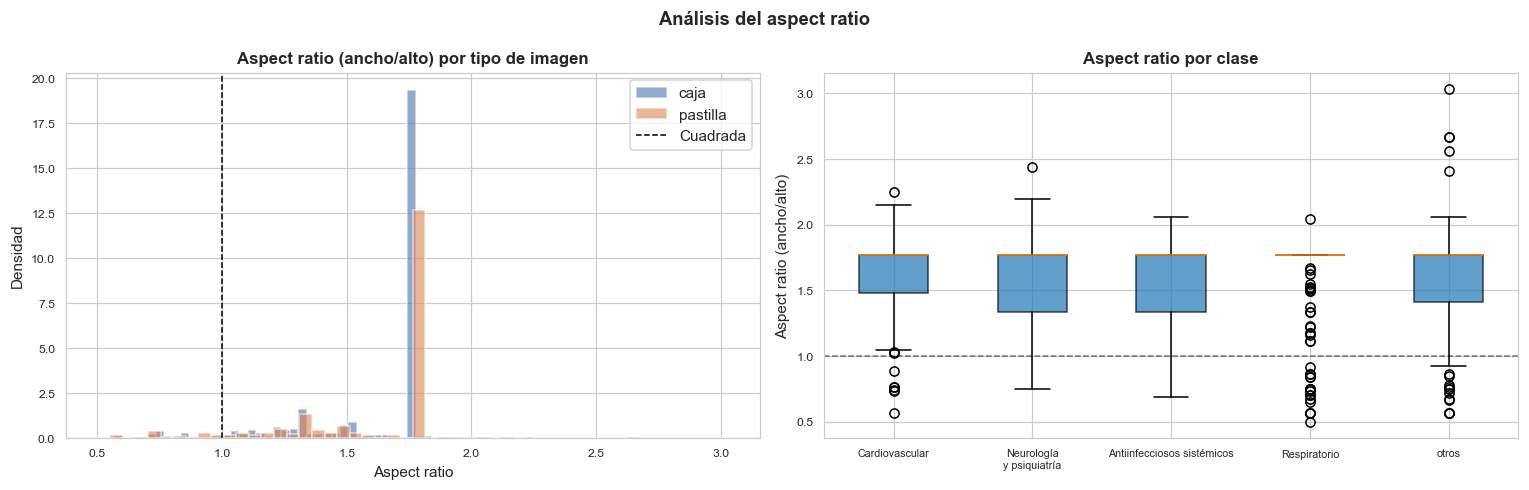


── Estadísticas de aspect ratio ──
            count  mean   std   min   25%   50%   75%   max
image_type                                                 
caja        475.0  1.60  0.29  0.56  1.45  1.77  1.77  2.25
pastilla    520.0  1.61  0.33  0.50  1.43  1.77  1.77  3.03

Outliers de aspect ratio (fuera del rango [0.67, 2.07]): 20 (2.0%)

── Recomendación de resolución para entrenamiento ──
   Mediana de dimensiones: 200 × 113 px
   Resolución objetivo sugerida: 224 × 224 (estándar ImageNet/transfer learning)
   Alternativa mayor precisión:  384 × 384 (EfficientNet, ViT)


In [8]:
OUTPUT_DIR = Path('output')
# Análisis específico del aspect ratio
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Histograma de aspect ratio por tipo de imagen
for tipo in ['caja', 'pastilla']:
    sub = df_props[df_props['image_type'] == tipo]['aspect']
    axes[0].hist(sub, bins=50, alpha=0.6, label=tipo, color=COLOR_TIPO[tipo], density=True)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1, label='Cuadrada')
axes[0].set_title('Aspect ratio (ancho/alto) por tipo de imagen', fontweight='bold')
axes[0].set_xlabel('Aspect ratio')
axes[0].set_ylabel('Densidad')
axes[0].legend()

# Distribución normalizada en escala log (para detectar outliers)
axes[1].boxplot([df_props[df_props['clase'] == c]['aspect'] for c in CLASES],
                patch_artist=True,
                boxprops=dict(alpha=0.7))
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xticklabels(
    [c.replace(' y ', '\ny ').replace(', ', ',\n') for c in CLASES], fontsize=7)
axes[1].set_title('Aspect ratio por clase', fontweight='bold')
axes[1].set_ylabel('Aspect ratio (ancho/alto)')

plt.suptitle('Análisis del aspect ratio', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_aspect_ratio.png', bbox_inches='tight')
plt.show()

print('\n── Estadísticas de aspect ratio ──')
print(df_props.groupby('image_type')['aspect'].describe().round(2).to_string())
print()

# Outliers: imágenes muy apaisadas o muy verticales
q_low, q_high = df_props['aspect'].quantile([0.01, 0.99])
outliers = df_props[(df_props['aspect'] < q_low) | (df_props['aspect'] > q_high)]
print(f'Outliers de aspect ratio (fuera del rango [{q_low:.2f}, {q_high:.2f}]): '
      f'{len(outliers)} ({len(outliers)/len(df_props)*100:.1f}%)')

# Recomendación de resolución target
mediana_w = int(df_props['width'].median())
mediana_h = int(df_props['height'].median())
print(f'\n Recomendación de resolución para entrenamiento')
print(f'Mediana de dimensiones: {mediana_w} × {mediana_h} px')
print(f'Resolución objetivo sugerida: 224 × 224 (estándar ImageNet/transfer learning)')
print(f'Alternativa mayor precisión:  384 × 384 (EfficientNet, ViT)')

El análisis del aspect ratio permite evaluar la geometría básica de las imágenes del dataset y comprobar si existen diferencias relevantes según el tipo de imagen o la clase terapéutica. Los resultados muestran que la mayoría de las muestras presentan proporciones mayores que 1, lo que indica un claro predominio de imágenes apaisadas frente a imágenes cuadradas. Este patrón aparece tanto en caja como en pastilla, aunque con cierta variabilidad y presencia de algunos outliers.

A nivel de clase, las distribuciones están bastante solapadas, con medianas similares entre grupos. Esto sugiere que el aspect ratio no constituye una característica discriminativa fuerte para la clasificación, aunque sí describe una propiedad estructural importante del dataset. Además, la detección de outliers confirma la existencia de un pequeño conjunto de imágenes con proporciones inusuales, que conviene tener en cuenta en el preprocesado.

# BLOQUE 2 — Análisis visual por clase

En las siguientes secciones se analiza visualmente el contenido de las imágenes de cada clase. El objetivo es entender qué aspecto tienen los medicamentos de cada categoría terapéutica, qué patrones visuales son comunes dentro de cada clase y qué diferencias existen entre clases. 
Para cada clase se presentan: un mosaico de imágenes representativas, histogramas de color RGB, y estadísticas de brillo y contraste.

## 5. Funciones auxiliares para análisis visual

Definimos las funciones que se usarán en las secciones 6–9 para el análisis visual de cada clase.

In [19]:
def show_mosaic(df_clase, clase, image_type=None, n=12, cols=6, title_suffix=''):
    """
    Muestra un mosaico de n imágenes de una clase.
    image_type: 'caja', 'pastilla' o None (mezcla ambos).
    """
    sub = df_clase[df_clase['clase'] == clase]
    if image_type:
        sub = sub[sub['image_type'] == image_type]
    paths = sub['image_path'].dropna().tolist()
    paths = random.sample(paths, min(n, len(paths)))

    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.2))
    axes = np.array(axes).flatten()

    for ax, p in zip(axes, paths):
        try:
            img = Image.open(p).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.set_facecolor('#eee')
        ax.axis('off')
    for ax in axes[len(paths):]:
        ax.axis('off')

    tipo_label = image_type if image_type else 'caja + pastilla'
    plt.suptitle(f'{clase}  —  {tipo_label}{title_suffix}',
                 fontsize=12, fontweight='bold', color=PALETTE.get(clase, 'black'))
    plt.tight_layout()
    fname = f'eda_mosaic_{clase[:15].replace(" ","_")}_{tipo_label[:5]}.png'
    plt.savefig(fname, bbox_inches='tight')
    plt.show()


def get_color_stats(paths, n=150):
    """
    Lee hasta n imágenes y devuelve arrays de píxeles R, G, B
    y estadísticas de brillo y contraste.
    """
    R, G, B = [], [], []
    brightness, contrast = [], []

    sampled = random.sample(paths, min(n, len(paths)))
    for p in sampled:
        try:
            img = np.array(Image.open(p).convert('RGB').resize((128, 128)))
            R.extend(img[:,:,0].flatten().tolist())
            G.extend(img[:,:,1].flatten().tolist())
            B.extend(img[:,:,2].flatten().tolist())
            gray = img.mean(axis=2)
            brightness.append(gray.mean())
            contrast.append(gray.std())
        except Exception:
            pass

    return np.array(R), np.array(G), np.array(B), np.array(brightness), np.array(contrast)


def plot_color_histograms(paths_por_clase, titulo=''):
    """
    Histogramas RGB superpuestos para todas las clases.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    ch_colors = ['red', 'green', 'blue']
    ch_names  = ['Canal R (rojo)', 'Canal G (verde)', 'Canal B (azul)']

    for cls, paths in paths_por_clase.items():
        R, G, B, _, _ = get_color_stats(paths, n=100)
        for ax, ch_data, ch_col in zip(axes, [R, G, B], ch_colors):
            ax.hist(ch_data, bins=64, alpha=0.35, density=True,
                    color=PALETTE[cls], label=cls)

    for ax, name in zip(axes, ch_names):
        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('Valor de píxel (0–255)')
        ax.set_ylabel('Densidad')
        ax.legend(fontsize=7)

    plt.suptitle(f'Histogramas de color RGB — {titulo}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'eda_color_{titulo[:20].replace(" ","_")}.png', bbox_inches='tight')
    plt.show()


def plot_brightness_contrast(df_work):
    """
    Boxplots de brillo y contraste medio por clase.
    """
    stats = {cls: {} for cls in CLASES}
    for cls in CLASES:
        paths = df_work[df_work['clase'] == cls]['image_path'].dropna().tolist()
        _, _, _, br, co = get_color_stats(paths, n=150)
        stats[cls]['brightness'] = br
        stats[cls]['contrast']   = co

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, key, label in [
        (axes[0], 'brightness', 'Brillo medio (0–255)'),
        (axes[1], 'contrast',   'Contraste (std de píxeles)'),
    ]:
        data = [stats[cls][key] for cls in CLASES]
        bp = ax.boxplot(data, patch_artist=True, notch=False)
        for patch, cls in zip(bp['boxes'], CLASES):
            patch.set_facecolor(PALETTE[cls])
            patch.set_alpha(0.7)
        ax.set_xticklabels(
            [c.replace(' y ', '\ny ').replace(', ', ',\n') for c in CLASES], fontsize=7
        )
        ax.set_title(label, fontweight='bold')
        ax.set_ylabel(label)

    plt.suptitle('Brillo y contraste por clase', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_brillo_contraste.png', bbox_inches='tight')
    plt.show()

    # Estadísticas numéricas
    print('Brillo medio por clase:')
    for cls in CLASES:
        br = stats[cls]['brightness']
        print(f'  {cls:<45}: media={br.mean():.1f}  std={br.std():.1f}')
    print('\nContraste medio por clase:')
    for cls in CLASES:
        co = stats[cls]['contrast']
        print(f'  {cls:<45}: media={co.mean():.1f}  std={co.std():.1f}')

print(' Funciones auxiliares definidas')

 Funciones auxiliares definidas


## 6. Mosaicos de imágenes por clase

Los mosaicos permiten inspeccionar visualmente qué aspecto tienen las imágenes de cada clase. Para cada clase mostramos por separado las imágenes de `caja` (envase) y `pastilla` (producto), ya que son visualmente muy distintas entre sí pero pertenecen a la misma categoría terapéutica.

Este análisis es fundamental para confirmar que las etiquetas son correctas y para identificar patrones visuales dominantes dentro de cada clase (por ejemplo, que los medicamentos cardiovasculares suelen venir en blísters, o que los dermatológicos son típicamente tubos o cremas).

MOSAICOS DE CAJAS (ENVASES) POR CLASE


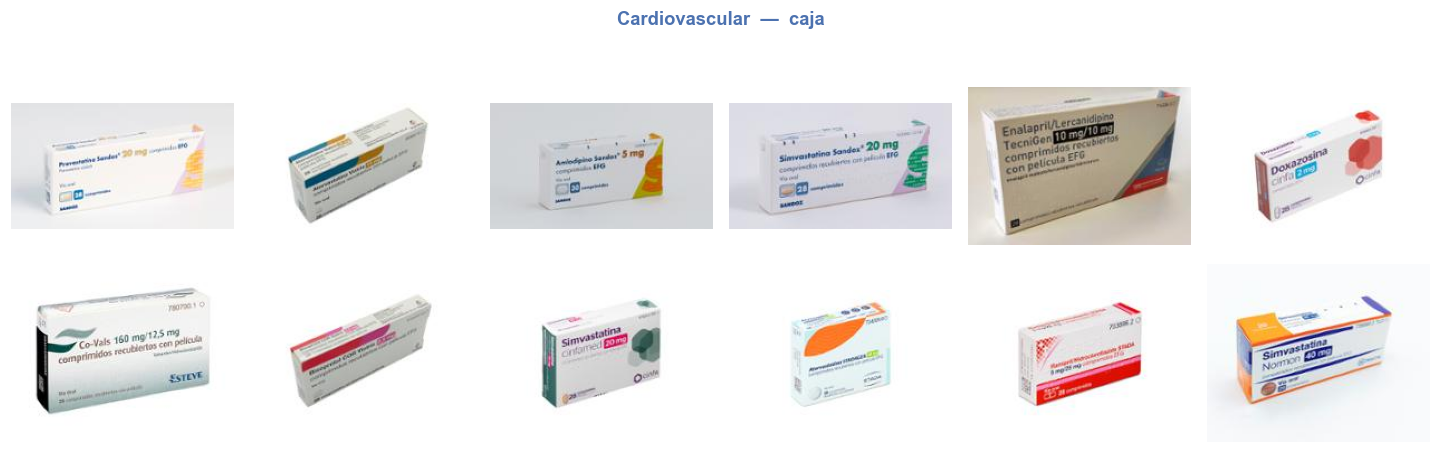

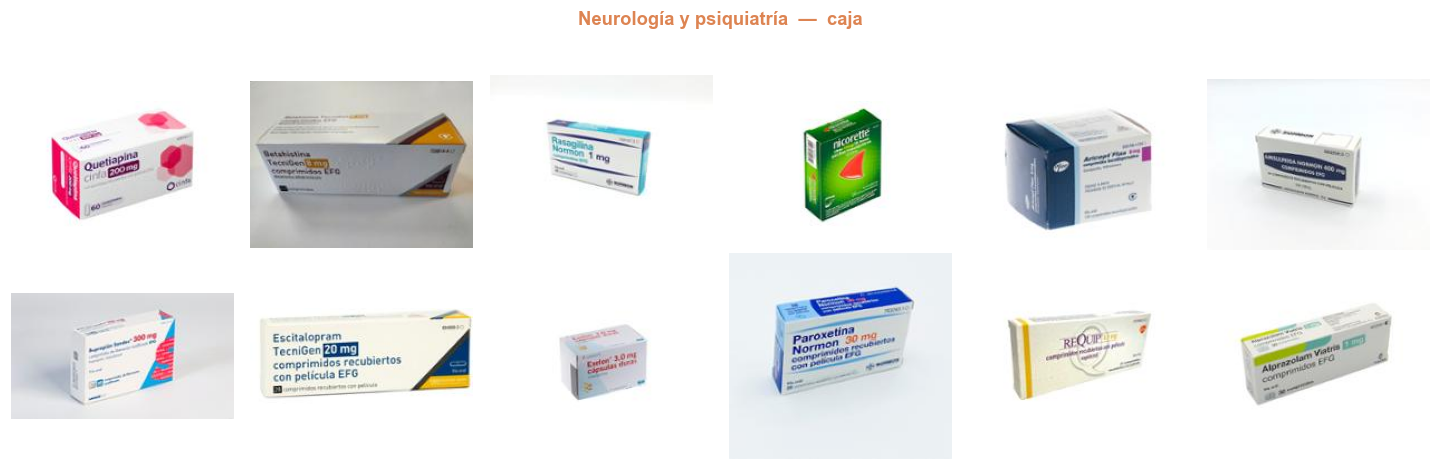

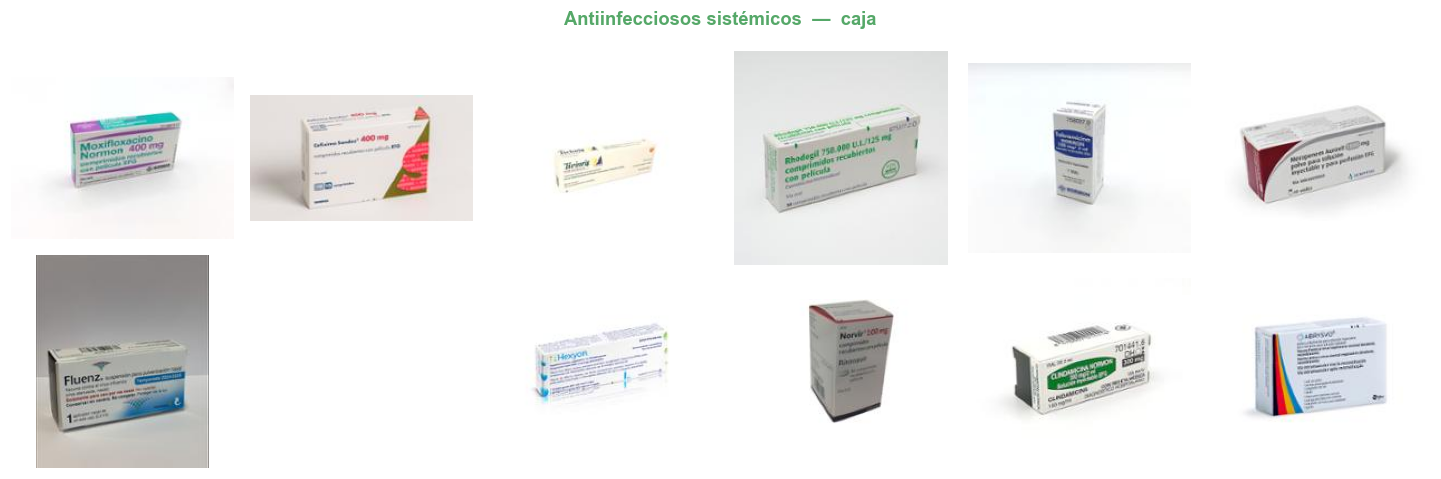

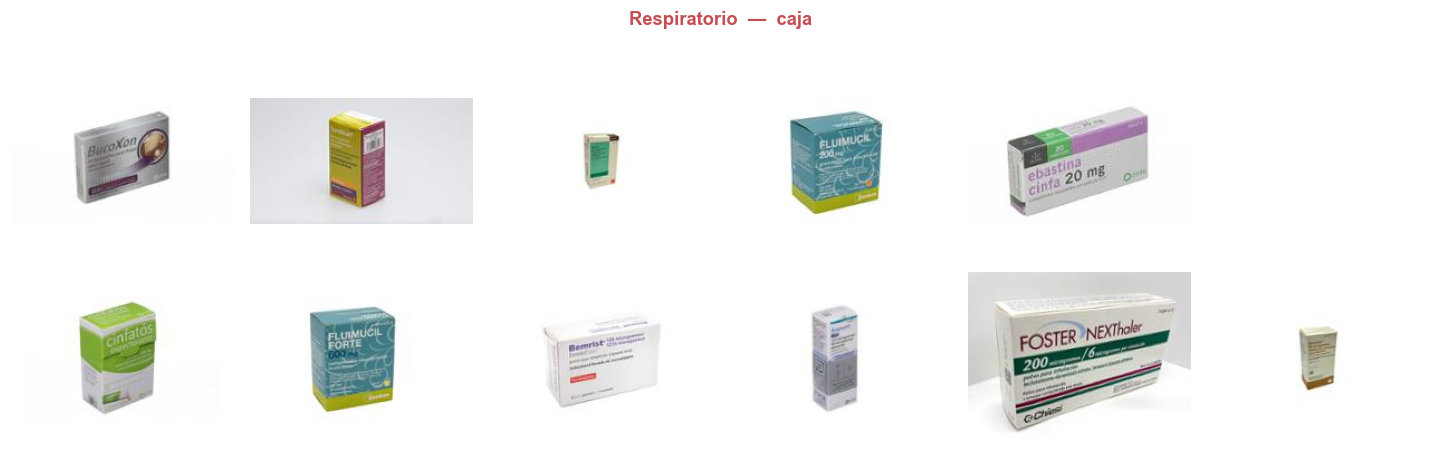

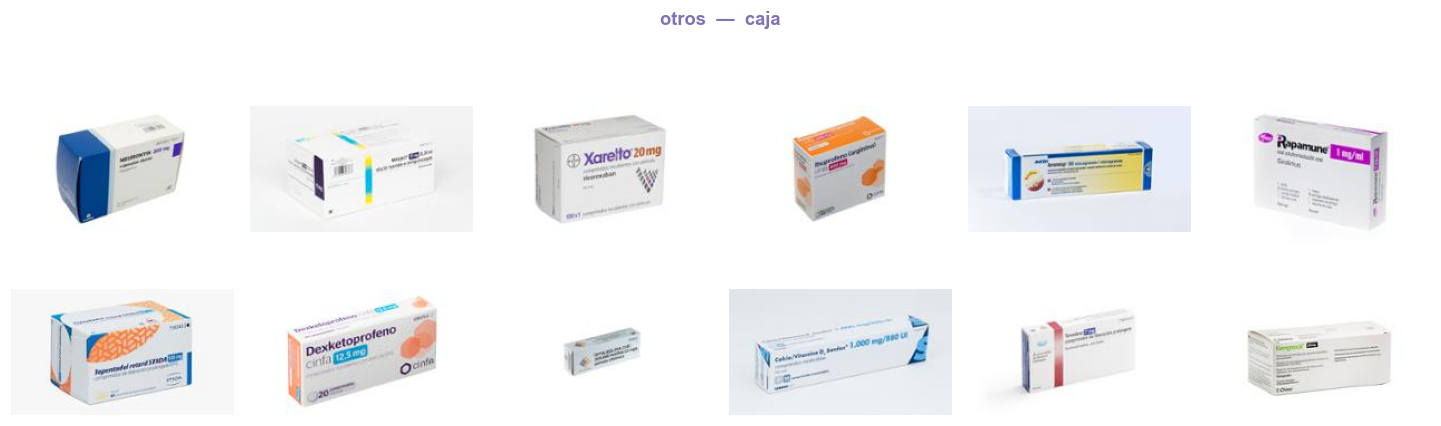

In [10]:
# Mosaico de cajas (envases) por cada una de las 5 clases
print('='*60)
print('MOSAICOS DE CAJAS POR CLASE')
print('='*60)
for cls in CLASES:
    show_mosaic(df, cls, image_type='caja', n=12, cols=6)

MOSAICOS DE PASTILLAS (PRODUCTOS) POR CLASE


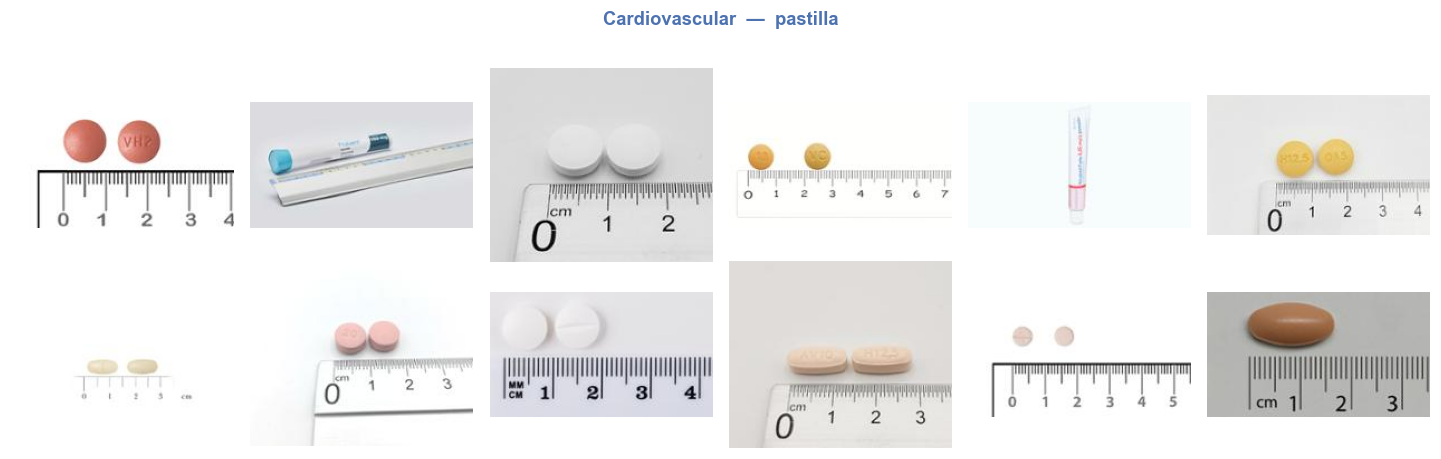

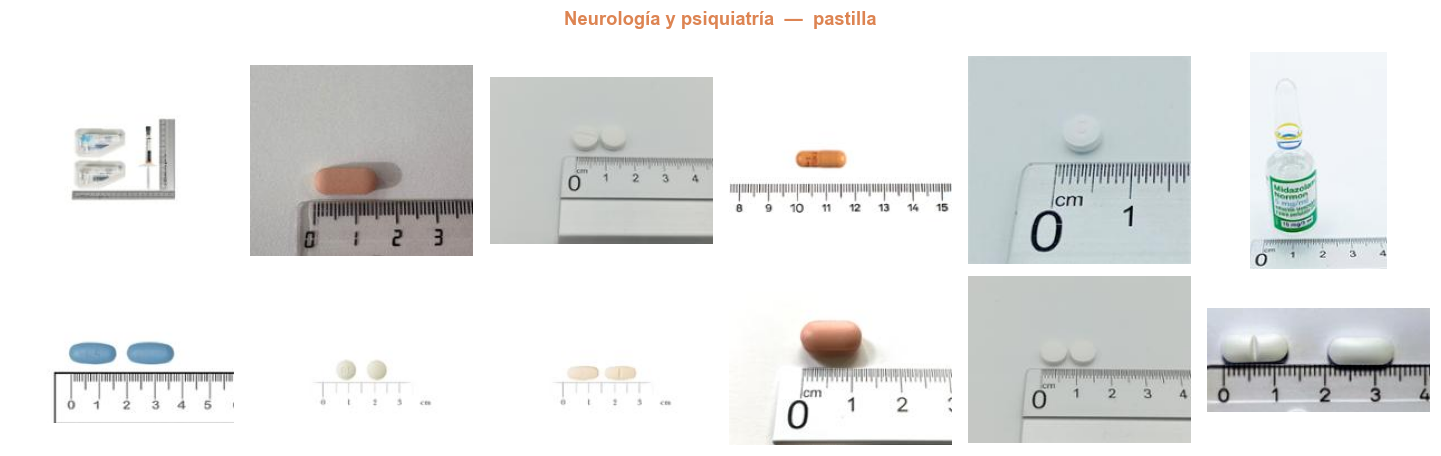

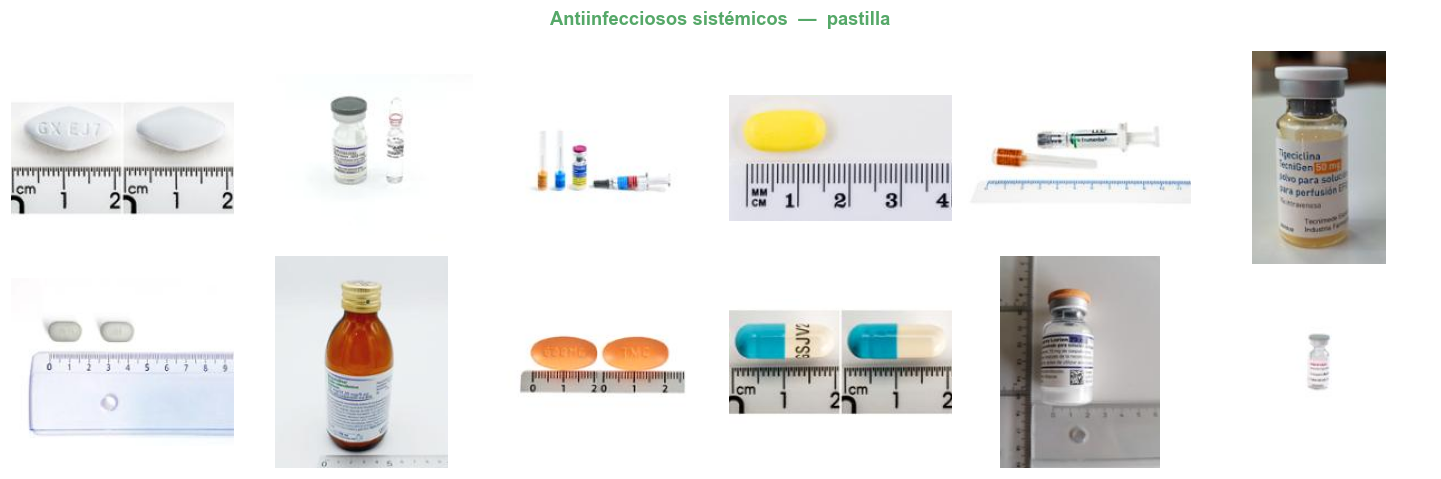

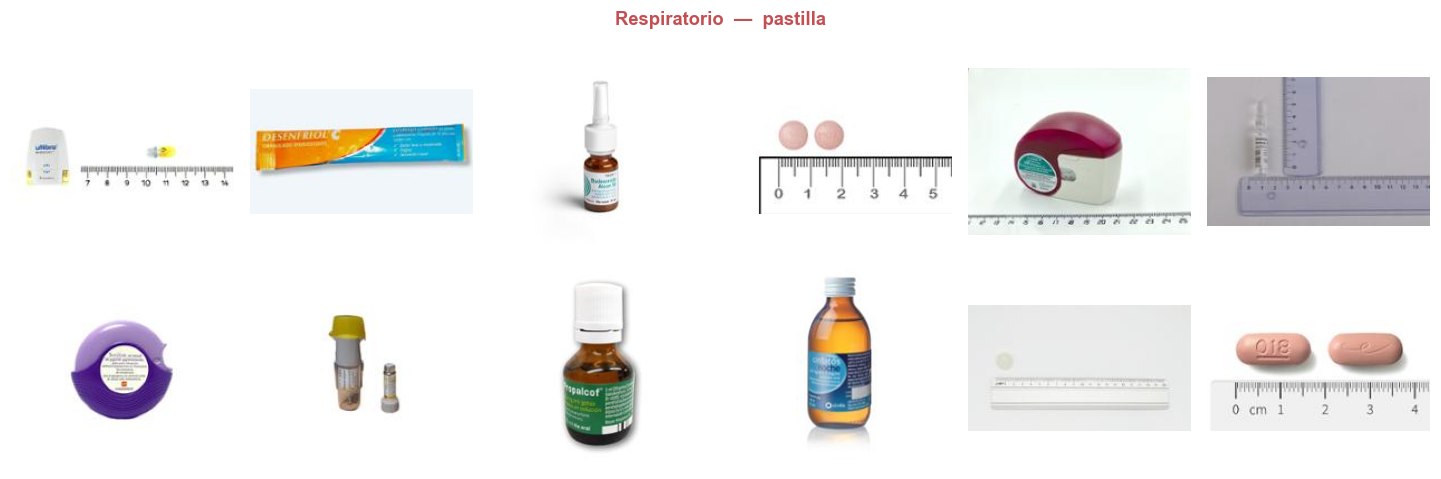

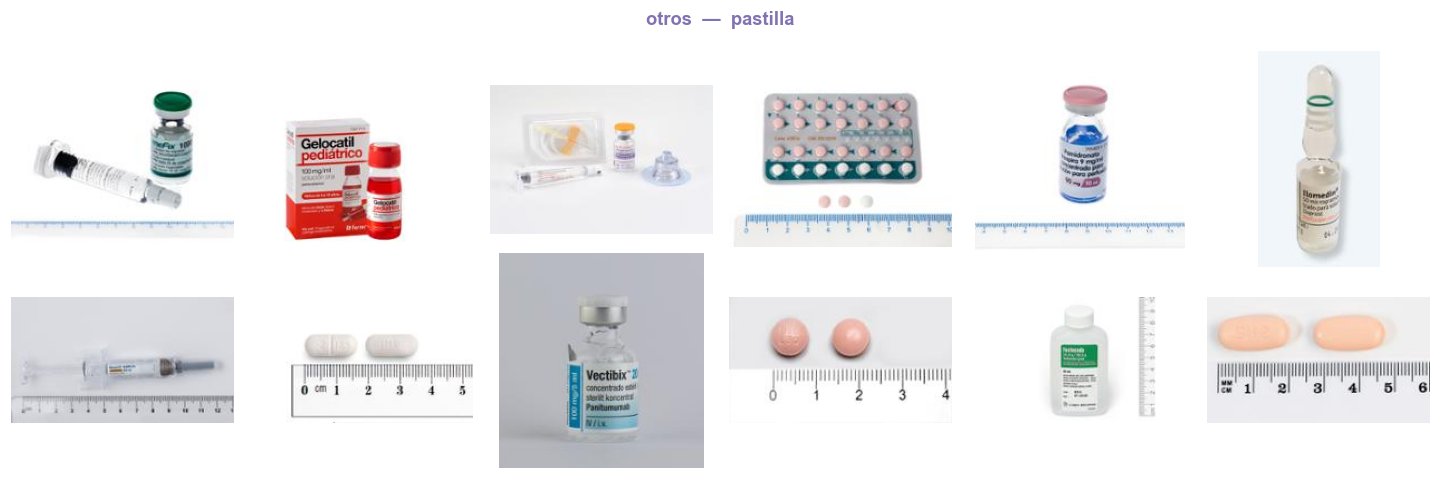

In [11]:
# Mosaico de pastillas (productos) por cada una de las 5 clases
print('='*60)
print('MOSAICOS DE PASTILLAS POR CLASE')
print('='*60)
for cls in CLASES:
    show_mosaic(df, cls, image_type='pastilla', n=12, cols=6)

Este análisis muestra que las clases terapéuticas presentan una separabilidad visual limitada. Dentro de cada clase existe una elevada variabilidad en el diseño de los envases, incluyendo diferencias en orientación, proporciones, distribución del texto y combinaciones de color. Al mismo tiempo, se observa un fuerte solapamiento visual entre clases distintas, lo que sugiere que la categoría terapéutica general no se corresponde con un patrón visual homogéneo.

Este resultado era esperable, ya que las etiquetas utilizadas describen la función farmacológica del medicamento y no una característica visual directa del envase. Por ello, la tarea de clasificación de imágenes resulta compleja. En fases posteriores será importante controlar cuidadosamente la partición del dataset para evitar que el modelo memorice medicamentos concretos en lugar de aprender patrones generalizables de clase.

## 7. Análisis de color por clase

A priori el color puede ser una de las señales visuales más inmediatas en las imágenes de medicamentos. Los envases farmacéuticos parecen que utilizan colores corporativos y de categoría (los antibióticos suelen tener colores llamativos, los cardiovasculares tienden a tonos más neutros), mientras que las formas farmacéuticas tienen colores característicos según su composición. Pero esta creencia no es del todo real como hemos podido intuir en la sección anterior. Para asegurarnos se van a analizar por separado las imágenes de caja y pastilla para detectar si el color es más discriminativo en uno u otro tipo. También se comparan los histogramas entre clases para identificar qué canales RGB son más informativos para la clasificación y de esta manera obtener una respuesta más objetiva.

Un histograma concentrado en valores altos (cerca de 255) indica imágenes con fondos blancos o productos de color claro. Una distribución más plana indica mayor variabilidad de color dentro de la clase.

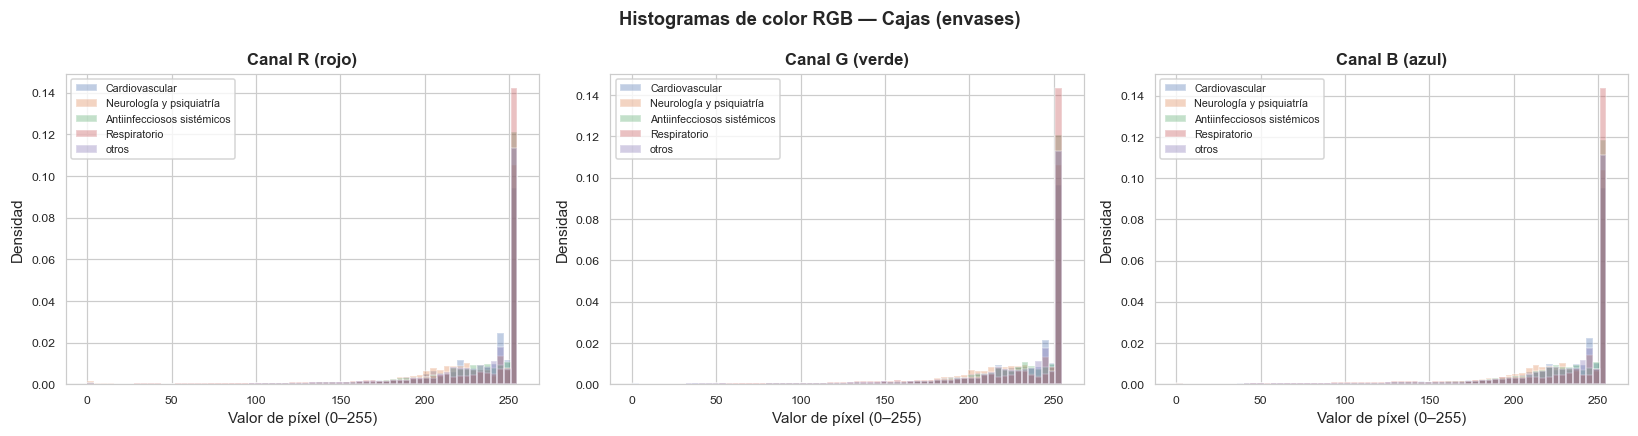

In [12]:
# Histogramas RGB para imágenes de CAJA
paths_caja = {
    cls: df[(df['clase'] == cls) & (df['image_type'] == 'caja')]['image_path'].dropna().tolist()
    for cls in CLASES
}
plot_color_histograms(paths_caja, titulo='Cajas (envases)')

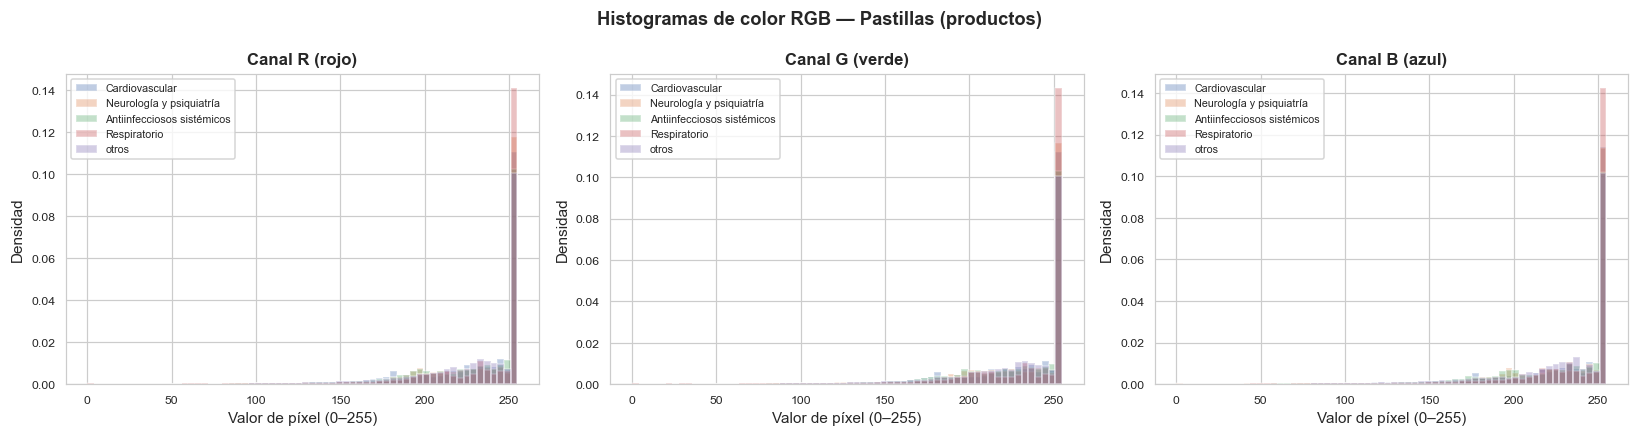

In [13]:
# Histogramas RGB para imágenes de PASTILLA
paths_past = {
    cls: df[(df['clase'] == cls) & (df['image_type'] == 'pastilla')]['image_path'].dropna().tolist()
    for cls in CLASES
}
plot_color_histograms(paths_past, titulo='Pastillas (productos)')

El análisis de color RGB en las imágenes de cajas muestra una fuerte concentración de píxeles en valores altos en los tres canales, lo que refleja el predominio de envases con fondos blancos o muy claros. Las distribuciones de las distintas clases terapéuticas presentan un alto grado de solapamiento, sin diferencias cromáticas globales claramente separadoras como se había intuido. En consecuencia, el color global del envase no parece constituir una señal discriminativa fuerte para la clasificación por macroclase_15_nombre, por lo que el modelo deberá apoyarse en patrones visuales más complejos que la simple distribución de color.

## 8. Brillo y contraste por clase

El brillo medio y el contraste (desviación estándar de los valores de gris) son propiedades globales de la imagen que dicen mucho sobre su naturaleza:

- **Brillo alto** (valores cercanos a 255): imágenes con fondos blancos, típico de envases y fotos de estudio. Indican que el objeto de interés ocupa poco espacio relativo en la imagen.
- **Brillo bajo**: imágenes más oscuras, fondos de color o medicamentos de colores oscuros.
- **Contraste alto**: la imagen tiene mucha variación interna, posiblemente con texto, bordes definidos o múltiples colores.
- **Contraste bajo**: imágenes más homogéneas, típico de cremas o geles con fondos claros.

Si dos clases tienen distribuciones de brillo y contraste muy distintas, el modelo puede aprender estas características como señales discriminativas. Si son similares, el modelo necesitará capturar patrones más sutiles.

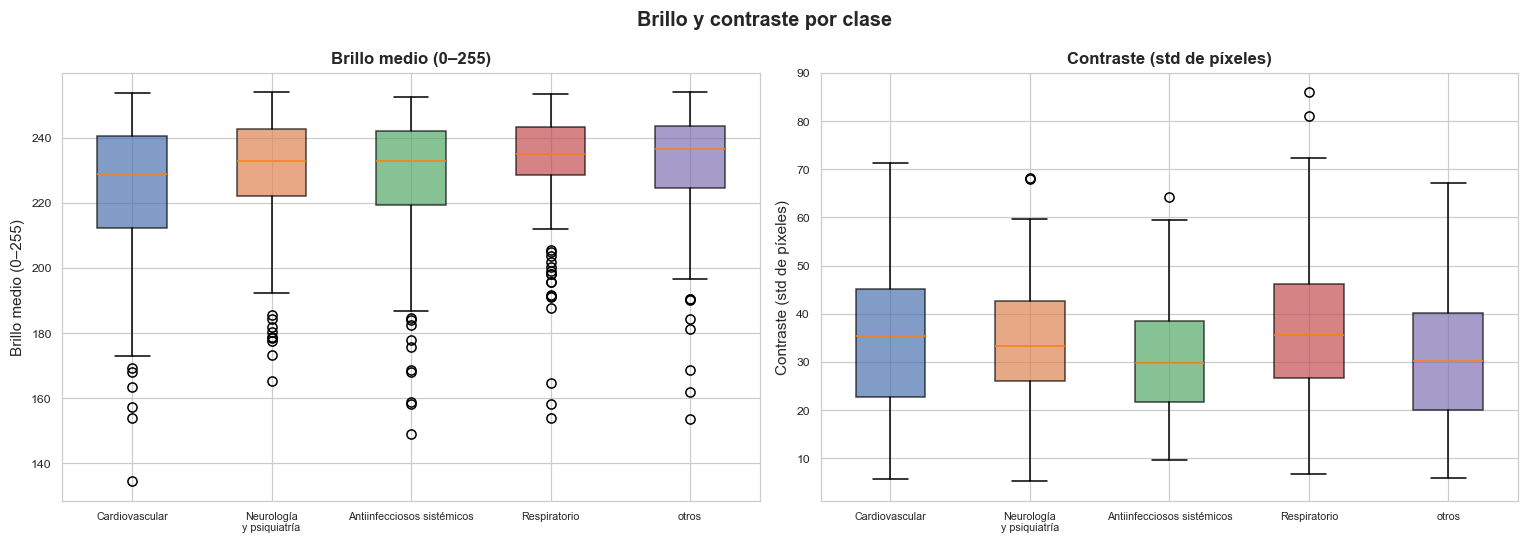

Brillo medio por clase:
  Cardiovascular                               : media=223.0  std=23.8
  Neurología y psiquiatría                     : media=229.5  std=19.1
  Antiinfecciosos sistémicos                   : media=226.8  std=21.6
  Respiratorio                                 : media=231.4  std=17.8
  otros                                        : media=231.8  std=18.5

Contraste medio por clase:
  Cardiovascular                               : media=34.5  std=14.6
  Neurología y psiquiatría                     : media=32.8  std=13.6
  Antiinfecciosos sistémicos                   : media=31.1  std=11.9
  Respiratorio                                 : media=36.4  std=14.7
  otros                                        : media=30.8  std=12.5


In [20]:
plot_brightness_contrast(df)

El análisis de brillo y contraste por clase muestra que las imágenes presentan un comportamiento bastante homogéneo entre grupos terapéuticos. El brillo medio se concentra en valores altos en todas las clases, lo que confirma el predominio de imágenes claras y fondos blancos en el dataset. En cuanto al contraste, aunque se observan pequeñas diferencias en la dispersión y en la posición de algunas medianas, las distribuciones están ampliamente solapadas. En conjunto, estos resultados sugieren que ni el brillo ni el contraste constituyen señales visuales suficientemente discriminativas para separar de forma clara las clases terapéuticas, por lo que el modelo deberá apoyarse en patrones más complejos que estas propiedades globales.

## 9. Imagen media y varianza de píxeles por clase

La imagen media de una clase es el promedio píxel a píxel de todas sus imágenes (redimensionadas al mismo tamaño). Si la imagen media muestra formas reconocibles, significa que los objetos de esa clase están en posiciones consistentes y tienen formas similares. Si es borrosa y uniforme, la variabilidad interna de la clase es alta.

La imagen de varianza muestra en qué zonas de la imagen hay más variación entre ejemplos de la misma clase. Las zonas con alta varianza son las más informativas para el modelo porque son donde las imágenes difieren más entre sí, y también donde hay más señal discriminativa respecto a otras clases.

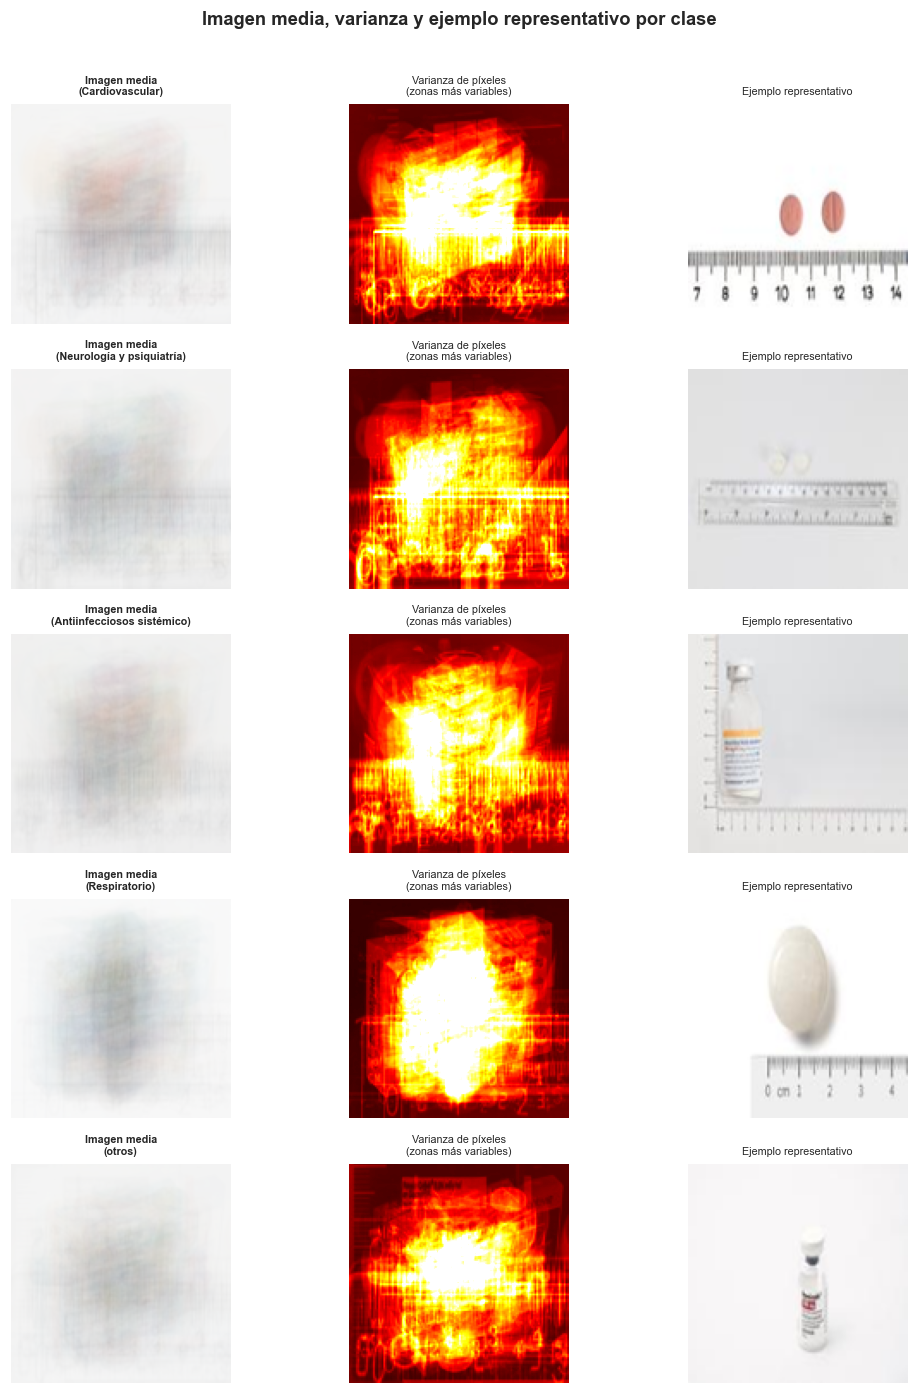

→ Clases con imagen media muy borrosa tienen alta variabilidad interna.
  Clases con imagen media reconocible tienen alta coherencia visual.


In [12]:
IMG_SIZE = (128, 128)
N_PIXEL  = 80   # imágenes por clase para calcular media/varianza

fig, axes = plt.subplots(len(CLASES), 3, figsize=(10, len(CLASES) * 2.5))

for i, cls in enumerate(CLASES):
    paths = df[df['clase'] == cls]['image_path'].dropna().tolist()
    paths_s = random.sample(paths, min(N_PIXEL, len(paths)))

    imgs = []
    for p in paths_s:
        try:
            arr = np.array(Image.open(p).convert('RGB').resize(IMG_SIZE)) / 255.0
            imgs.append(arr)
        except Exception:
            pass

    if not imgs:
        continue

    stack    = np.stack(imgs, axis=0)          # (N, H, W, 3)
    img_mean = stack.mean(axis=0)              # imagen media
    img_var  = stack.var(axis=0).mean(axis=2)  # varianza (escala de grises)

    # Ejemplo representativo: imagen más cercana a la media
    dists = [np.linalg.norm(im - img_mean) for im in imgs]
    idx_rep = int(np.argmin(dists))

    axes[i, 0].imshow(np.clip(img_mean, 0, 1))
    axes[i, 0].set_title(f'Imagen media\n({cls[:25]})', fontsize=7, fontweight='bold')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_var, cmap='hot', vmin=0, vmax=0.05)
    axes[i, 1].set_title('Varianza de píxeles\n(zonas más variables)', fontsize=7)
    axes[i, 1].axis('off')

    try:
        axes[i, 2].imshow(np.array(Image.open(paths_s[idx_rep]).convert('RGB').resize(IMG_SIZE)))
    except Exception:
        pass
    axes[i, 2].set_title('Ejemplo representativo', fontsize=7)
    axes[i, 2].axis('off')

plt.suptitle('Imagen media, varianza y ejemplo representativo por clase',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_imagen_media_varianza.png', bbox_inches='tight')
plt.show()
print(' Clases con imagen media muy borrosa tienen alta variabilidad interna.')
print('  Clases con imagen media reconocible tienen alta coherencia visual.')

En este caso, las imágenes medias resultan muy borrosas y poco definidas, lo que indica una elevada heterogeneidad dentro de cada grupo terapéutico. Esto sugiere que los medicamentos pertenecientes a una misma clase no comparten una estructura visual estable ni una apariencia homogénea.

Los mapas de varianza muestran que las zonas con mayor variabilidad se concentran principalmente en la región central de la imagen, donde aparece el medicamento, y en la parte inferior, donde suele situarse la escala o regla de referencia. Por tanto, la variación entre muestras parece estar más relacionada con la forma física del producto, su posición y elementos del montaje fotográfico que con la clase terapéutica en sí.

En conjunto, este análisis refuerza la idea de que la clasificación visual por macroclase_15_nombre es una tarea compleja, ya que las clases no presentan una firma visual global clara. Además, la mezcla de presentaciones muy distintas dentro de una misma categoría incrementa todavía más la variabilidad interna observada.

## 10. Visualización del espacio de features con t-SNE

Proyectamos a 2D las imágenes usando features profundos extraídos de un modelo pre-entrenado (o un fallback simple de histograma HSV si no hay torch). Si las clases se separan visualmente en el espacio t-SNE, es una señal de que un modelo razonable debería poder clasificarlas. Si están completamente mezcladas, el problema será duro.

Usamos `PCA(n=50) → TSNE(n=2)` como es estándar para acelerar y estabilizar.

Features ResNet18: 100%|██████████| 47/47 [00:47<00:00,  1.01s/it]


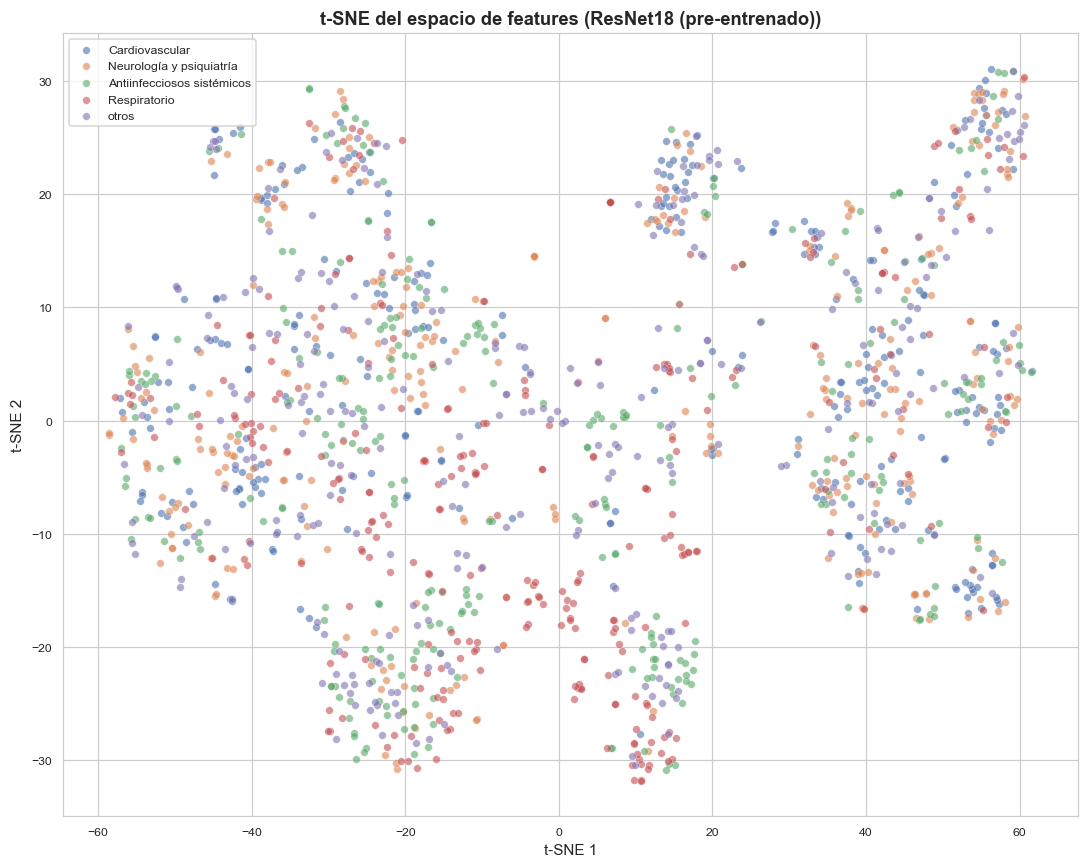


→ Interpretación: si las clases forman clusters separables visualmente,
  un modelo convolucional debería ser capaz de clasificarlas con éxito.
  Si están completamente mezcladas, hay solapamiento visual fuerte y habrá que
  apoyarse en transfer learning y data augmentation agresivo.


In [ ]:
def extract_features_deep(paths, batch_size=32, max_images=1500):
    """Extrae features con un ResNet18 pre-entrenado (pooling global).
    Si torch no está disponible, hace fallback a histograma HSV concatenado."""
    try:
        import torch
        import torchvision.transforms as T
        import torchvision.models as M

        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        model  = M.resnet18(weights=M.ResNet18_Weights.DEFAULT)
        model  = torch.nn.Sequential(*list(model.children())[:-1])  # quitar FC final
        model.eval().to(device)

        tf = T.Compose([
            T.Resize((224, 224)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        paths = paths[:max_images]
        feats = []
        with torch.no_grad():
            for i in tqdm(range(0, len(paths), batch_size), desc='Features ResNet18'):
                batch_paths = paths[i:i+batch_size]
                imgs = []
                for p in batch_paths:
                    try:
                        imgs.append(tf(Image.open(p).convert('RGB')))
                    except Exception:
                        imgs.append(torch.zeros(3, 224, 224))
                batch = torch.stack(imgs).to(device)
                f = model(batch).cpu().numpy().reshape(len(imgs), -1)
                feats.append(f)
        return np.vstack(feats), 'ResNet18 (pre-entrenado)'

    except Exception as e:
        print(f'  [torch no disponible o error: {e}] — usando fallback HSV histogram')
        paths = paths[:max_images]
        feats = []
        for p in tqdm(paths, desc='Features HSV hist'):
            try:
                img = np.array(Image.open(p).convert('RGB').resize((128, 128)))
                hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
                hist = np.concatenate([
                    np.histogram(hsv[:,:,c], bins=32, range=(0, 256))[0]
                    for c in range(3)
                ]).astype(np.float32)
                hist /= (hist.sum() + 1e-6)
                feats.append(hist)
            except Exception:
                feats.append(np.zeros(96, dtype=np.float32))
        return np.vstack(feats), 'HSV histogram (fallback)'


# Tomamos una muestra estratificada para que no explote el t-SNE
N_TSNE_POR_CLASE = 300
muestra_tsne = (
    df.groupby('clase', group_keys=False)
      .apply(lambda x: x.sample(min(N_TSNE_POR_CLASE, len(x)), random_state=SEED))
      .reset_index(drop=True)
)
paths_tsne = muestra_tsne['image_path'].tolist()
clases_tsne = muestra_tsne['clase'].values

feats, origen_feats = extract_features_deep(paths_tsne, max_images=len(paths_tsne))

# PCA→t-SNE
if feats.shape[1] > 50:
    feats_pca = PCA(n_components=50, random_state=SEED).fit_transform(feats)
else:
    feats_pca = feats
emb_tsne = TSNE(n_components=2, perplexity=30, random_state=SEED,
                init='pca', learning_rate='auto').fit_transform(feats_pca)

fig, ax = plt.subplots(figsize=(10, 8))
for cls in CLASES:
    mask = clases_tsne == cls
    ax.scatter(emb_tsne[mask, 0], emb_tsne[mask, 1],
               c=PALETTE[cls], alpha=0.6, s=25, label=cls, edgecolors='white', linewidth=0.3)
ax.set_title(f't-SNE del espacio de features ({origen_feats})', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='best')
ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_tsne.png', bbox_inches='tight')
plt.show()

print('\n→ Interpretación: si las clases forman clusters separables visualmente,')
print('  un modelo convolucional debería ser capaz de clasificarlas con éxito.')
print('  Si están completamente mezcladas, hay solapamiento visual fuerte y habrá que')
print('  apoyarse en transfer learning y data augmentation agresivo.')


---
# BLOQUE 3 — Desequilibrio y estrategia de balanceo

## 10. Análisis del desequilibrio de clases

Con las 5 clases definidas, analizamos en detalle el desequilibrio y sus consecuencias para el entrenamiento. El problema es doble:

1. **Durante el entrenamiento**: el modelo verá muchas más veces los ejemplos de las clases mayoritarias y aprenderá mejor sus patrones. Los gradientes de las clases minoritarias se actualizarán con menor frecuencia.
2. **En la evaluación**: métricas como la *accuracy* pueden ser engañosas. Un modelo que siempre prediga la clase más frecuente puede tener una accuracy alta pero ser inútil en la práctica. Por eso se usa F1-macro.

Cuantificamos el desequilibrio con tres métricas: el ratio max/min, la entropía normalizada (1 = perfectamente uniforme) y los pesos de clase que se aplicarían con `class_weight='balanced'`.

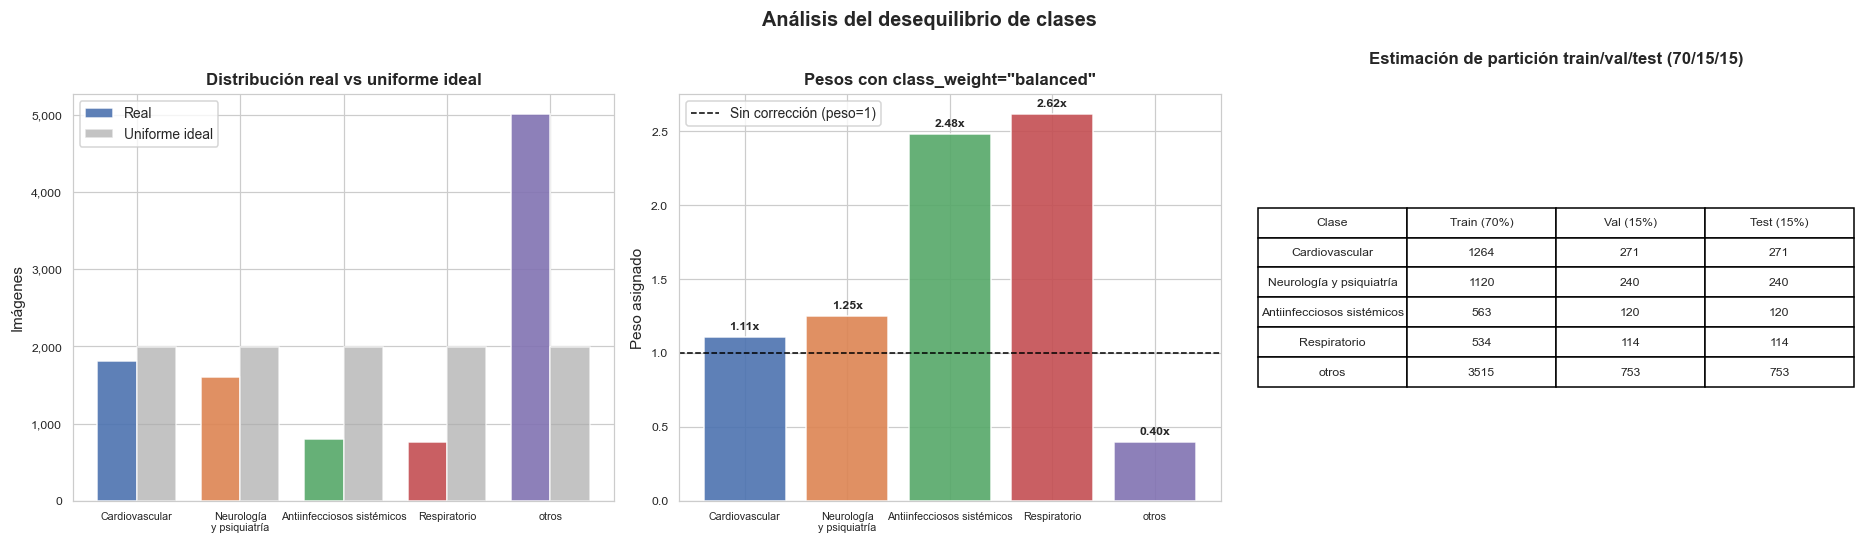

Ratio de desequilibrio (max/min): 6.6x
Entropía normalizada:             0.837  (1.0 = uniforme)

⚠️  Desequilibrio SIGNIFICATIVO → imprescindible data augmentation + class_weight.


In [ ]:
conteos = df['clase'].value_counts().reindex(CLASES)
total   = len(df)

n_clases   = len(CLASES)
uniforme   = total / n_clases
pesos_bal  = total / (n_clases * conteos.values)
probs      = conteos.values / total
ent_norm   = entropy(probs) / np.log(n_clases)
ratio      = conteos.max() / conteos.min()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Real vs uniforme 
x = np.arange(n_clases)
w = 0.38
axes[0].bar(x - w/2, conteos.values, width=w,
            color=[PALETTE[c] for c in CLASES], edgecolor='white', alpha=0.9, label='Real')
axes[0].bar(x + w/2, [uniforme]*n_clases, width=w,
            color='#aaa', edgecolor='white', alpha=0.7, label='Uniforme ideal')
axes[0].set_xticks(x)
axes[0].set_xticklabels(
    [c.replace(' y ', '\ny ').replace(', ', ',\n') for c in CLASES], fontsize=7
)
axes[0].set_title('Distribución real vs uniforme ideal', fontweight='bold')
axes[0].set_ylabel('Imágenes')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pesos de clase_weight='balanced' 
axes[1].bar(CLASES, pesos_bal,
            color=[PALETTE[c] for c in CLASES], edgecolor='white', alpha=0.9)
axes[1].axhline(1.0, color='black', linestyle='--', linewidth=1, label='Sin corrección (peso=1)')
for i, (cls, peso) in enumerate(zip(CLASES, pesos_bal)):
    axes[1].text(i, peso + 0.05, f'{peso:.2f}x', ha='center', fontsize=8, fontweight='bold')
axes[1].set_xticklabels(
    [c.replace(' y ', '\ny ').replace(', ', ',\n') for c in CLASES], fontsize=7
)
axes[1].set_title('Pesos con class_weight="balanced"', fontweight='bold')
axes[1].set_ylabel('Peso asignado')
axes[1].legend(fontsize=9)

# Estimación train/val/test 
df_split = pd.DataFrame({
    'Clase': CLASES,
    'Train (70%)': (conteos.values * 0.70).astype(int),
    'Val (15%)':   (conteos.values * 0.15).astype(int),
    'Test (15%)':  (conteos.values * 0.15).astype(int),
})
axes[2].axis('off')
tabla = axes[2].table(
    cellText=df_split.values,
    colLabels=df_split.columns,
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(8)
tabla.scale(1.1, 1.7)
axes[2].set_title('Estimación de partición train/val/test (70/15/15)',
                  fontweight='bold', pad=20)

plt.suptitle('Análisis del desequilibrio de clases', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_desequilibrio.png', bbox_inches='tight')
plt.show()

print(f'Ratio de desequilibrio (max/min): {ratio:.1f}x')
print(f'Entropía normalizada:             {ent_norm:.3f}  (1.0 = uniforme)')
print()
if ratio > 5:
    print('Desequilibrio SIGNIFICATIVO: para solucionarlo data augmentation + class_weight.')
elif ratio > 2:
    print('Desequilibrio MODERADO: para solucionarlo class_weight + F1-macro.')
else:
    print('Distribución razonablemente equilibrada.')

El análisis del desequilibrio de clases muestra que el dataset no presenta una distribución homogénea de la variable objetivo. La clase otros concentra aproximadamente la mitad de las imágenes, mientras que respiratorio y antiinfecciosos sistémicos son claramente minoritarias. El ratio entre la clase más frecuente y la menos frecuente es de 6,6x, lo que confirma un desequilibrio significativo.

Los pesos estimados mediante class_weight="balanced" reflejan esta situación: las clases minoritarias requieren una compensación cercana a 2,5 veces respecto al entrenamiento sin corrección, mientras que la clase otros recibe un peso reducido. Esto indica que, si no se aplican estrategias de balanceo, el modelo tenderá a sesgarse hacia la clase mayoritaria.

En consecuencia, para el entrenamiento será necesario incorporar medidas como class_weight, técnicas de data augmentation en las clases minoritarias y métricas de evaluación sensibles al desbalance, especialmente F1-macro. De este modo se podrá valorar mejor el rendimiento real del modelo en todas las clases y no solo en la categoría dominante.

## 11. Split train / val / test estratificado (ANTES del augmentation)

###  Por qué es crítico hacer el split ANTES del augmentation

Si primero aumentamos las imágenes y luego hacemos el split, pueden acabar **imágenes aumentadas en train cuyos originales están en val/test** -> data leakage -> métricas infladas que no reflejan la realidad.

### Por qué splitear por `nregistro` (medicamento), no por imagen

Un mismo medicamento (`nregistro`) suele tener **varias imágenes** (caja + pastillas en distintos ángulos). Si splitemos por imagen, imágenes del mismo medicamento pueden caer en train y en val -> el modelo ya "conoce" ese medicamento en val. Splitear por `nregistro` agrupa todas las imágenes de un medicamento en el mismo split.

### Estrategia

1. Split a nivel de `nregistro` usando `GroupShuffleSplit` **estratificado** por clase.
2. Proporciones: **70% train / 15% val / 15% test**.
3. Verificamos que la proporción de clases se mantiene en cada split.

In [24]:
from sklearn.model_selection import train_test_split
GROUP_COL    = 'nregistro' 

# Tabla con una fila por medicamento (con su clase)
df_groups = (df.groupby(GROUP_COL)['clase']
               .agg(lambda x: x.mode().iloc[0])
               .reset_index()
               .rename(columns={'clase': 'clase_grp'}))

# Split 1: train vs temp (85% train+val, 15% test) — estratificado por clase
gr_trainval, gr_test = train_test_split(
    df_groups,
    test_size=0.15,
    stratify=df_groups['clase_grp'],
    random_state=SEED,
)

# Split 2: train vs val dentro de trainval (≈15% del total)
gr_train, gr_val = train_test_split(
    gr_trainval,
    test_size=0.15 / 0.85,
    stratify=gr_trainval['clase_grp'],
    random_state=SEED,
)

split_map = {}
for g in gr_train[GROUP_COL]: split_map[g] = 'train'
for g in gr_val[GROUP_COL]:   split_map[g] = 'val'
for g in gr_test[GROUP_COL]:  split_map[g] = 'test'

df['split'] = df[GROUP_COL].map(split_map)

# Verificación: proporciones por split y por clase
print('── Distribución por split ──')
print(f'  Train: {(df["split"]=="train").sum():>6,}  '
      f'({(df["split"]=="train").mean()*100:.1f}%)')
print(f'  Val:   {(df["split"]=="val").sum():>6,}  '
      f'({(df["split"]=="val").mean()*100:.1f}%)')
print(f'  Test:  {(df["split"]=="test").sum():>6,}  '
      f'({(df["split"]=="test").mean()*100:.1f}%)')

print('\n── Proporción de clases por split (%) ──')
tab = df.groupby(['split', 'clase']).size().unstack(fill_value=0)
tab_pct = tab.div(tab.sum(axis=1), axis=0) * 100
print(tab_pct.round(1).to_string())

# Verificación: no hay leakage por nregistro
overlap = set(df[df['split']=='train'][GROUP_COL]) & set(df[df['split']=='val'][GROUP_COL])
overlap |= set(df[df['split']=='train'][GROUP_COL]) & set(df[df['split']=='test'][GROUP_COL])
overlap |= set(df[df['split']=='val'][GROUP_COL])   & set(df[df['split']=='test'][GROUP_COL])
print(f'\n── Verificación de leakage ──')
print(f'  Medicamentos (nregistro) compartidos entre splits: {len(overlap)} ✔' if not overlap
      else f'  {len(overlap)} medicamentos compartidos entre splits — revisar')

# Guardar CSV con el split
df.to_csv(OUTPUT_DIR / 'dataset_split.csv', index=False)
print(f'\n✔ Guardado: {OUTPUT_DIR / "dataset_split.csv"}')


── Distribución por split ──
  Train:  6,999  (70.0%)
  Val:    1,500  (15.0%)
  Test:   1,499  (15.0%)

── Proporción de clases por split (%) ──
clase  Antiinfecciosos sistémicos  Cardiovascular  Neurología y psiquiatría  Respiratorio  otros
split                                                                                           
test                          8.0            18.1                      16.1           7.6   50.2
train                         8.1            18.1                      16.0           7.6   50.2
val                           8.1            18.1                      15.9           7.6   50.3

── Verificación de leakage ──
  Medicamentos (nregistro) compartidos entre splits: 0 ✔

✔ Guardado: output/dataset_split.csv


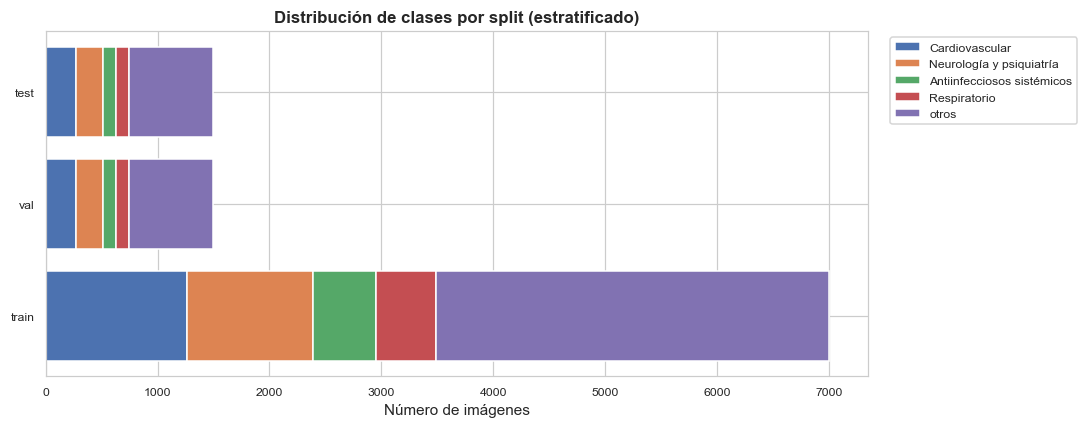

In [25]:
# Visualización del split
fig, ax = plt.subplots(figsize=(10, 4))
tab = df.groupby(['split', 'clase']).size().unstack(fill_value=0).reindex(['train','val','test'])
bottom = np.zeros(len(tab))
for cls in CLASES:
    ax.barh(tab.index, tab[cls].values, left=bottom,
            color=PALETTE[cls], label=cls, edgecolor='white')
    bottom += tab[cls].values
ax.set_title('Distribución de clases por split (estratificado)', fontweight='bold')
ax.set_xlabel('Número de imágenes')
ax.legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_split.png', bbox_inches='tight')
plt.show()


La partición del dataset se ha realizado de forma estratificada por clase y agrupada por nregistro, de modo que todas las imágenes pertenecientes a un mismo medicamento quedan asignadas al mismo subconjunto (train, val o test). Esto es fundamental para evitar fuga de información entre splits, ya que impide que el modelo vea en entrenamiento imágenes del mismo medicamento que después aparecen en validación o prueba.

Además, la estratificación mantiene una distribución de clases similar en los tres subconjuntos, lo que favorece una evaluación más estable y representativa del problema real.

## 12. Análisis del desequilibrio de clases

Ahora calculamos el desbalance sobre el split de train (es el único que vamos a balancear).

### ¿Por qué data augmentation?

El data augmentation tiene dos funciones distintas en este proyecto:

1. **Regularización general** (se aplica a todas las clases durante el entrenamiento): transformaciones aleatorias que evitan que el modelo memorice las imágenes y mejoran su capacidad de generalización.

2. **Balanceo de clases** (se aplica solo a las clases minoritarias): generar imágenes sintéticas adicionales a partir de las existentes hasta equiparar el número de muestras entre clases. Esto es preferible a simplemente repetir las imágenes originales (oversampling puro) porque cada imagen aumentada es ligeramente diferente, aportando variabilidad.

### Transformaciones utilizadas

Se utilizan transformaciones que son realistas para imágenes de medicamentos: no tiene sentido voltear verticalmente un envase de medicamento, pero sí es razonable rotarlo ligeramente, cambiar el brillo o aplicar un zoom. Las transformaciones deben ser lo suficientemente suaves como para que la imagen aumentada siga siendo reconocible y perteneciente a la misma clase.

En la celda siguiente se muestran visualmente ejemplos de imágenes aumentadas y se calcula cuántas imágenes sintéticas se necesitan por clase para alcanzar el nivel de la clase más frecuente.

DESEQUILIBRIO DE CLASES EN TRAIN
  Total imágenes train:           6,999
  Media uniforme (ideal):         1,400
  Imbalance ratio (max/min):      6.57x
  Índice de uniformidad (0–1):    0.838  (1 = perfecto)



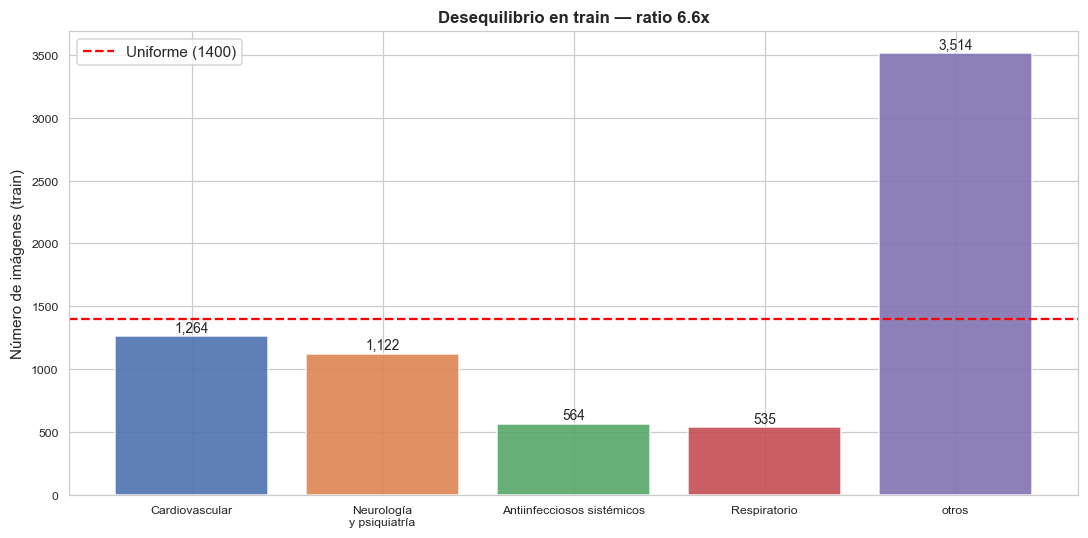

In [26]:
df_train = df[df['split'] == 'train'].copy()

conteos_tr = df_train['clase'].value_counts().reindex(CLASES)
total_tr   = len(df_train)
n_clases   = len(CLASES)
uniforme   = total_tr / n_clases
imbalance_ratio = conteos_tr.max() / conteos_tr.min()

# Entropía normalizada como medida de uniformidad
p = conteos_tr / total_tr
entropia     = -np.sum(p * np.log(p + 1e-9))
entropia_max = np.log(n_clases)
indice_unif  = entropia / entropia_max

print('='*60)
print('DESEQUILIBRIO DE CLASES EN TRAIN')
print('='*60)
print(f'  Total imágenes train:           {total_tr:,}')
print(f'  Media uniforme (ideal):         {uniforme:,.0f}')
print(f'  Imbalance ratio (max/min):      {imbalance_ratio:.2f}x')
print(f'  Índice de uniformidad (0–1):    {indice_unif:.3f}  (1 = perfecto)')
print()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(n_clases), conteos_tr.values,
              color=[PALETTE[c] for c in CLASES], edgecolor='white', alpha=0.9)
ax.axhline(uniforme, color='red', linestyle='--', label=f'Uniforme ({uniforme:.0f})')
ax.set_xticks(range(n_clases))
ax.set_xticklabels([c.replace(' y ', '\ny ').replace(', ', ',\n') for c in CLASES],
                   fontsize=8)
ax.set_ylabel('Número de imágenes (train)')
ax.set_title(f'Desequilibrio en train — ratio {imbalance_ratio:.1f}x',
             fontweight='bold')
for bar, v in zip(bars, conteos_tr.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + total_tr*0.005, f'{v:,}',
            ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_desbalance_train.png', bbox_inches='tight')
plt.show()


---
# BLOQUE 4 — Pipelines de data augmentation

## 14. Pipelines offline diferenciados (caja / pastilla)

- **`augment_caja`**: pipeline conservador (sin flip, rotación ±5°, cambios de color suaves). El texto y el diseño del packaging son señal discriminativa; no los queremos destruir.
- **`augment_pastilla`**: más libertad (flip, rotación ±15°, más zoom), pero con **detección automática de regla de escala** para evitar romperla.


In [27]:
# PIPELINE OFFLINE PARA CAJAS

def augment_caja(img: Image.Image, seed=None, return_info=False):
    """Augmentation conservador para cajas (envases).

    Permitidas:
      - Rotación ±5° · Zoom 93–100% · Brillo ±20% · Contraste ±15%
      - Saturación ±15% · Ruido gaussiano σ=3

    Prohibidas:
      - Flip (el texto quedaría ilegible)
      - Rotaciones grandes o cambios de color extremos
    """
    if seed is not None:
        random.seed(seed); np.random.seed(seed)

    img = img.copy()
    w, h = img.size
    info = {}

    info['rotate']  = random.uniform(-5, 5)
    img = img.rotate(info['rotate'], expand=False, fillcolor=(255, 255, 255))

    info['zoom'] = random.uniform(0.93, 1.0)
    dw, dh = int(w*(1-info['zoom'])/2), int(h*(1-info['zoom'])/2)
    if dw > 0 and dh > 0:
        img = img.crop((dw, dh, w-dw, h-dh)).resize((w, h), Image.BILINEAR)

    info['brightness'] = random.uniform(0.80, 1.20)
    img = ImageEnhance.Brightness(img).enhance(info['brightness'])

    info['contrast']   = random.uniform(0.85, 1.15)
    img = ImageEnhance.Contrast(img).enhance(info['contrast'])

    info['saturation'] = random.uniform(0.85, 1.15)
    img = ImageEnhance.Color(img).enhance(info['saturation'])

    info['noise_sigma'] = 3
    arr = np.array(img, dtype=np.float32)
    arr = np.clip(arr + np.random.normal(0, info['noise_sigma'], arr.shape), 0, 255).astype(np.uint8)
    img = Image.fromarray(arr)

    return (img, info) if return_info else img

# PIPELINE OFFLINE PARA PASTILLAS

def _detectar_regla(img: Image.Image, umbral_varianza=800.0) -> bool:
    """Detecta regla de escala en el borde inferior (var. en franja inferior)."""
    arr = np.array(img.convert('L'))
    h = arr.shape[0]
    franja = arr[int(h*0.88):, :]
    return float(franja.var()) > umbral_varianza


def augment_pastilla(img: Image.Image, seed=None, tiene_regla=None, return_info=False):
    """Augmentation para pastillas con detección automática de regla de escala."""
    if seed is not None:
        random.seed(seed); np.random.seed(seed)

    img = img.copy()
    w, h = img.size

    if tiene_regla is None:
        tiene_regla = _detectar_regla(img)

    info = {'tiene_regla': bool(tiene_regla)}

    if tiene_regla:
        info['rotate'] = random.uniform(-5, 5)
        info['zoom']   = random.uniform(0.93, 1.0)
        info['flip']   = False
    else:
        info['rotate'] = random.uniform(-15, 15)
        info['zoom']   = random.uniform(0.85, 1.0)
        info['flip']   = random.random() > 0.5

    if info['flip']:
        img = ImageOps.mirror(img)
    img = img.rotate(info['rotate'], expand=False, fillcolor=(255, 255, 255))

    dw, dh = int(w*(1-info['zoom'])/2), int(h*(1-info['zoom'])/2)
    if dw > 0 and dh > 0:
        img = img.crop((dw, dh, w-dw, h-dh)).resize((w, h), Image.BILINEAR)

    info['brightness'] = random.uniform(0.75, 1.25)
    img = ImageEnhance.Brightness(img).enhance(info['brightness'])
    info['contrast']   = random.uniform(0.80, 1.20)
    img = ImageEnhance.Contrast(img).enhance(info['contrast'])
    info['saturation'] = random.uniform(0.80, 1.20)
    img = ImageEnhance.Color(img).enhance(info['saturation'])

    info['noise_sigma'] = 5
    arr = np.array(img, dtype=np.float32)
    arr = np.clip(arr + np.random.normal(0, info['noise_sigma'], arr.shape), 0, 255).astype(np.uint8)
    img = Image.fromarray(arr)

    return (img, info) if return_info else img


def augment_image(img, image_type, seed=None, return_info=False):
    """Dispatcher: elige el pipeline según el tipo de imagen."""
    if image_type == 'caja':
        return augment_caja(img, seed=seed, return_info=return_info)
    elif image_type == 'pastilla':
        return augment_pastilla(img, seed=seed, return_info=return_info)
    else:
        raise ValueError(f"image_type desconocido: '{image_type}'")


print('Pipelines offline definidos:')
print('augment_caja()     — conservador (sin flip)')
print('augment_pastilla() — con detección de regla de escala')
print('augment_image()    — dispatcher automático')


Pipelines offline definidos:
  augment_caja()     — conservador (sin flip)
  augment_pastilla() — con detección de regla de escala
  augment_image()    — dispatcher automático


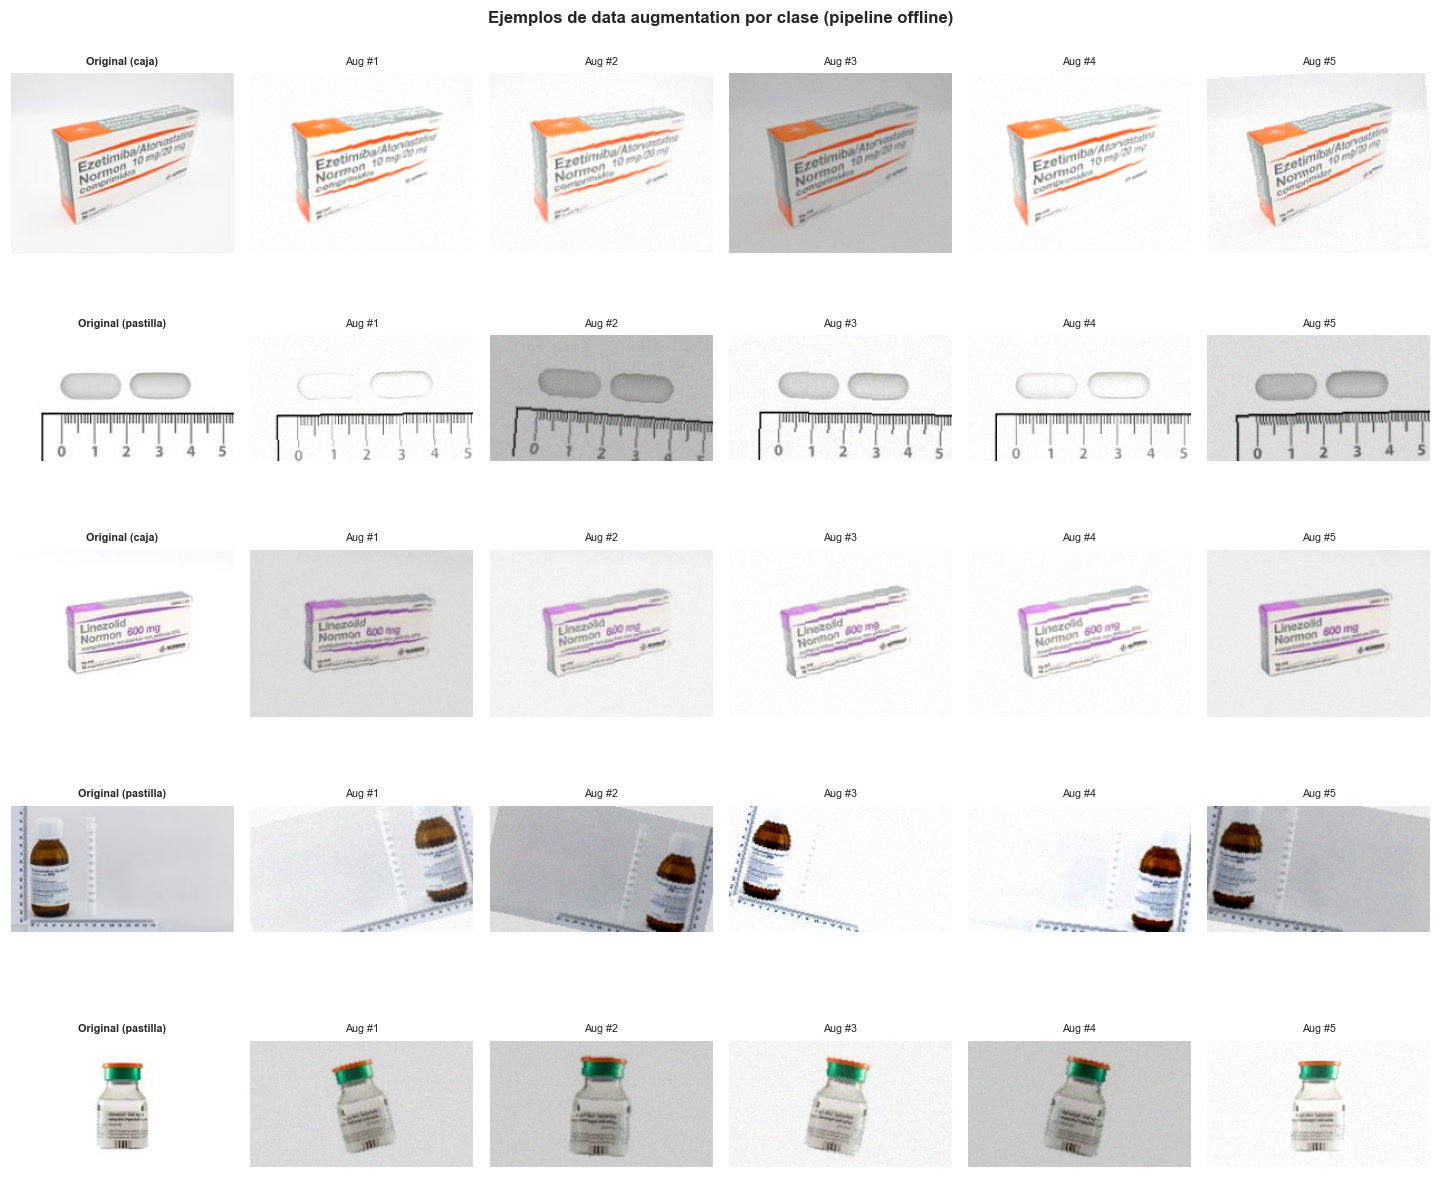

In [29]:
from PIL import Image, ImageEnhance, ImageOps, ImageFilter

# Visualización: original + 5 aumentaciones por clase 
N_AUG_SHOW = 5
fig, axes = plt.subplots(len(CLASES), N_AUG_SHOW + 1,
                          figsize=((N_AUG_SHOW + 1) * 2.2, len(CLASES) * 2.3))

for i, cls in enumerate(CLASES):
    paths = df_train[df_train['clase'] == cls]['image_path'].dropna().tolist()
    if not paths:
        continue
    src_path = random.choice(paths)
    tipo     = df_train[df_train['image_path'] == src_path]['image_type'].iloc[0]
    try:
        src_img = Image.open(src_path).convert('RGB')
    except Exception:
        continue

    axes[i, 0].imshow(src_img)
    axes[i, 0].set_title(f'Original ({tipo})', fontsize=7, fontweight='bold')
    axes[i, 0].set_ylabel(cls[:20], fontsize=7, color=PALETTE[cls], fontweight='bold')
    axes[i, 0].axis('off')

    for j in range(1, N_AUG_SHOW + 1):
        aug = augment_image(src_img, image_type=tipo, seed=j*100+i)
        axes[i, j].imshow(aug)
        axes[i, j].set_title(f'Aug #{j}', fontsize=7)
        axes[i, j].axis('off')

plt.suptitle('Ejemplos de data augmentation por clase (pipeline offline)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_aug_ejemplos.png', bbox_inches='tight')
plt.show()


## 15. Validación de la detección de regla de escala

Misma validación que en la versión anterior: muestreamos pastillas del train, medimos la varianza de la franja inferior y verificamos que el umbral de 800 separa correctamente los dos grupos.

Muestra n=200:  con regla=56 (28.0%)  |  sin regla=144 (72.0%)


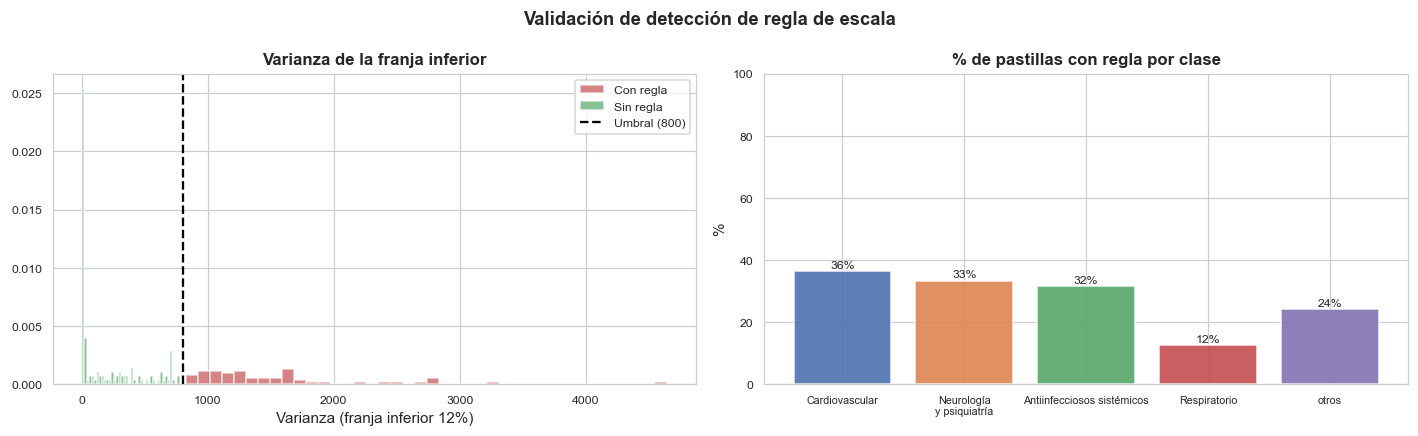

In [30]:
pastillas = df_train[df_train['image_type'] == 'pastilla'].dropna(subset=['image_path'])
N_CHECK = 200

muestra_check = pastillas.sample(min(N_CHECK, len(pastillas)), random_state=SEED)

resultados = []
for _, row in muestra_check.iterrows():
    try:
        img = Image.open(row['image_path']).convert('RGB')
        tiene_regla = _detectar_regla(img)
        arr = np.array(img.convert('L'))
        h = arr.shape[0]
        var_fr = float(arr[int(h*0.88):, :].var())
        resultados.append({
            'path':        row['image_path'],
            'clase':       row['clase'],
            'tiene_regla': tiene_regla,
            'varianza':    var_fr
        })
    except Exception:
        pass

df_det = pd.DataFrame(resultados)
n_con = df_det['tiene_regla'].sum()
pct   = n_con / len(df_det) * 100
print(f'Muestra n={len(df_det)}:  con regla={n_con} ({pct:.1f}%)  |  sin regla={len(df_det)-n_con} ({100-pct:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_det[df_det['tiene_regla']]['varianza'], bins=40, alpha=0.7,
             color='#C44E52', label='Con regla', density=True)
axes[0].hist(df_det[~df_det['tiene_regla']]['varianza'], bins=40, alpha=0.7,
             color='#55A868', label='Sin regla', density=True)
axes[0].axvline(800, color='black', linestyle='--', linewidth=1.5, label='Umbral (800)')
axes[0].set_title('Varianza de la franja inferior', fontweight='bold')
axes[0].set_xlabel('Varianza (franja inferior 12%)'); axes[0].legend(fontsize=8)

prop_regla = (df_det.groupby('clase')['tiene_regla'].mean() * 100)
prop_regla = prop_regla.reindex([c for c in CLASES if c in prop_regla.index])
axes[1].bar(prop_regla.index, prop_regla.values,
            color=[PALETTE.get(c,'#888') for c in prop_regla.index],
            edgecolor='white', alpha=0.9)
axes[1].set_title('% de pastillas con regla por clase', fontweight='bold')
axes[1].set_ylabel('%'); axes[1].set_ylim(0, 100)
axes[1].set_xticklabels(
    [c.replace(' y ', '\ny ').replace(', ', ',\n') for c in prop_regla.index], fontsize=7)
for i, v in enumerate(prop_regla.values):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontsize=8)

plt.suptitle('Validación de detección de regla de escala', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eda_deteccion_regla.png', bbox_inches='tight')
plt.show()


## 16. Plan de balanceo y generación del dataset balanceado

Ahora se aplica **solo sobre train**. La estructura de salida es:

```
data_augmented/train/<clase>/<tipo>/aug_XXXXX_<original_stem>.jpg
```

Y se genera un CSV `dataset_balanced.csv` con estas columnas adicionales:
- `augmented` (bool) — True si la fila es una imagen sintética
- `aug_source_path` (str) — ruta de la imagen original de la que se derivó
- `aug_transform` (str) — JSON con los parámetros exactos de la transformación
- `split` — siempre `train` para las sintéticas


In [31]:
# Plan 
conteos_tr = df_train['clase'].value_counts().reindex(CLASES)
n_objetivo = int(conteos_tr.max())

print('=' * 70)
print(f'PLAN DE BALANCEO (solo split=train)  |  Objetivo: {n_objetivo:,} img/clase')
print('=' * 70)
print(f'{"Clase":<45} {"Reales":>7} {"Sint.":>7} {"Total":>7} {"Factor":>7}')
print('-' * 70)

plan = []
for cls in CLASES:
    n_real = int(conteos_tr[cls])
    n_sint = max(0, n_objetivo - n_real)
    factor = n_sint / n_real if n_real > 0 else 0
    plan.append((cls, n_real, n_sint))
    print(f'{cls:<45} {n_real:>7,} {n_sint:>7,} {n_real+n_sint:>7,} {factor:>6.1f}x')

print('-' * 70)
print(f'Total tras balanceo: {n_objetivo * len(CLASES):,} imágenes de train')


PLAN DE BALANCEO (solo split=train)  |  Objetivo: 3,514 img/clase
Clase                                          Reales   Sint.   Total  Factor
----------------------------------------------------------------------
Cardiovascular                                  1,264   2,250   3,514    1.8x
Neurología y psiquiatría                        1,122   2,392   3,514    2.1x
Antiinfecciosos sistémicos                        564   2,950   3,514    5.2x
Respiratorio                                      535   2,979   3,514    5.6x
otros                                           3,514       0   3,514    0.0x
----------------------------------------------------------------------
Total tras balanceo: 17,570 imágenes de train


In [32]:
import json
def generate_balanced_train(
    df_train: pd.DataFrame,
    output_dir: Path,
    n_objetivo: int,
    clases: list,
    dry_run: bool = True,
) -> pd.DataFrame:
    """Genera imágenes sintéticas SOLO para el split de train.

    Devuelve un DataFrame con las filas originales + sintéticas, todas marcadas
    con split='train' y augmented=True/False.
    """
    output_dir  = Path(output_dir)
    conteos     = df_train['clase'].value_counts()
    nuevas_filas = []

    for cls in clases:
        n_real   = int(conteos.get(cls, 0))
        n_needed = n_objetivo - n_real
        if n_needed <= 0:
            print(f'  {cls}: no necesita augmentation ({n_real:,} imágenes)')
            continue

        print(f'  {cls}: generando {n_needed:,} imágenes sintéticas...')
        df_cls = df_train[df_train['clase'] == cls].dropna(subset=['image_path'])

        # Mantener proporción caja/pastilla original
        n_cajas     = (df_cls['image_type'] == 'caja').sum()
        total_cls   = len(df_cls)
        prop_caja   = n_cajas / total_cls if total_cls else 0.5

        for k in range(n_needed):
            tipo_src = 'caja' if random.random() < prop_caja else 'pastilla'
            pool = df_cls[df_cls['image_type'] == tipo_src]['image_path'].tolist()
            if not pool:
                pool = df_cls['image_path'].tolist()
                tipo_src = df_cls.iloc[k % len(df_cls)]['image_type']

            src_path = random.choice(pool)
            try:
                src_img = Image.open(src_path).convert('RGB')
                aug_img, info = augment_image(
                    src_img, image_type=tipo_src, seed=k, return_info=True
                )

                aug_name = f'aug_{k:05d}_{Path(src_path).stem}.jpg'
                cls_dir  = (output_dir / 'train'
                            / cls.replace(' ', '_').replace('/', '_')
                            / tipo_src)
                aug_path = cls_dir / aug_name

                if not dry_run:
                    cls_dir.mkdir(parents=True, exist_ok=True)
                    aug_img.save(str(aug_path), quality=92)

                # Heredar metadatos del original
                row_src = df_cls[df_cls['image_path'] == src_path].iloc[0].to_dict()
                row_src['image_path']      = str(aug_path)
                row_src['image_filename']  = aug_name
                row_src['augmented']       = True
                row_src['aug_source_path'] = src_path
                row_src['aug_transform']   = json.dumps(info, default=str)
                row_src['split']           = 'train'
                if 'sample_id' in row_src:
                    row_src['sample_id'] = f'{row_src["sample_id"]}_aug_{k:05d}'
                nuevas_filas.append(row_src)

            except Exception as e:
                pass

    return pd.DataFrame(nuevas_filas)


#  Ejecutar (por defecto dry_run=True, cambia a False para generar los archivos) 
DRY_RUN = False
AUG_ROOT     = Path('data_augmented')   # raíz de imágenes sintéticas
print(f'\nEjecutando generación (dry_run={DRY_RUN})...\n')
df_aug = generate_balanced_train(
    df_train=df_train,
    output_dir=AUG_ROOT,
    n_objetivo=n_objetivo,
    clases=CLASES,
    dry_run=DRY_RUN,
)
print(f'\nFilas sintéticas generadas: {len(df_aug):,}')



Ejecutando generación (dry_run=True)...

  Cardiovascular: generando 2,250 imágenes sintéticas...
  Neurología y psiquiatría: generando 2,392 imágenes sintéticas...
  Antiinfecciosos sistémicos: generando 2,950 imágenes sintéticas...
  Respiratorio: generando 2,979 imágenes sintéticas...
  otros: no necesita augmentation (3,514 imágenes)

→ Filas sintéticas generadas: 10,488


In [33]:
# Construir dataset_balanced.csv 
df['augmented']       = False
df['aug_source_path'] = np.nan
df['aug_transform']   = np.nan

if len(df_aug) > 0:
    # Alinear columnas
    for col in df.columns:
        if col not in df_aug.columns:
            df_aug[col] = np.nan
    df_aug = df_aug[df.columns]
    df_balanced = pd.concat([df, df_aug], ignore_index=True)
else:
    df_balanced = df.copy()

df_balanced.to_csv(OUTPUT_DIR / 'dataset_balanced.csv', index=False)

print('─' * 55)
print('RESUMEN DEL DATASET BALANCEADO')
print('─' * 55)
print(f'Total filas:              {len(df_balanced):>8,}')
print(f'Originales:               {(~df_balanced["augmented"]).sum():>8,}')
print(f'Sintéticas (solo train):  {df_balanced["augmented"].sum():>8,}')
print()
print('Distribución por split × augmented:')
tab = df_balanced.groupby(['split', 'augmented']).size().unstack(fill_value=0)
print(tab.to_string())
print()
print(f'Distribución de clases en TRAIN tras balanceo:')
print(df_balanced[df_balanced["split"]=="train"]["clase"].value_counts().reindex(CLASES).to_string())
print()
print(f'Guardado: {OUTPUT_DIR / "dataset_balanced.csv"}')


───────────────────────────────────────────────────────
  RESUMEN DEL DATASET BALANCEADO
───────────────────────────────────────────────────────
  Total filas:                20,486
  Originales:                  9,998
  Sintéticas (solo train):    10,488

  Distribución por split × augmented:
augmented  False  True 
split                  
test        1499      0
train       6999  10488
val         1500      0

  Distribución de clases en TRAIN tras balanceo:
clase
Cardiovascular                3502
Neurología y psiquiatría      3500
Antiinfecciosos sistémicos    3490
Respiratorio                  3481
otros                         3514

✔ Guardado: output/dataset_balanced.csv


## 17. Pipelines online para entrenamiento — PyTorch y TensorFlow/Keras

### Por qué online además del offline

El augmentation offline nos balancea las clases. Pero si entrenáramos muchas épocas viendo **siempre las mismas** imágenes aumentadas, el modelo acabaría memorizándolas. Para evitarlo, además aplicamos **augmentation ligero online** en cada batch, lo que garantiza que el modelo nunca ve dos veces exactamente la misma imagen.

El online es más ligero que el offline (sólo aplicamos lo suficiente para regularizar) porque el balanceo ya está hecho.

### Elementos clave

- **Solo en train**: `val` y `test` usan solo resize + normalización.
- **Normalización con stats de ImageNet** si vamos a usar transfer learning.
- **Parámetros suaves**: jitter ±15%, rotación ±10°, flip solo si el tipo lo permite.

In [34]:
# 17a. PIPELINE ONLINE — PYTORCH
"""
Pipeline de entrenamiento con PyTorch.
Requiere: torch, torchvision.

Uso:
    train_ds = MedicinesDataset(df_balanced, split='train', transform=train_tf)
    val_ds   = MedicinesDataset(df_balanced, split='val',   transform=eval_tf)
    test_ds  = MedicinesDataset(df_balanced, split='test',  transform=eval_tf)
"""

PIPELINE_PYTORCH = '''
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from PIL import Image

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── TRAIN: augmentation online ligero (el pesado ya es offline) ──────────────
train_tf = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.RandomCrop(IMG_SIZE),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── VAL / TEST: SIN augmentation ─────────────────────────────────────────────
eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class MedicinesDataset(Dataset):
    def __init__(self, df, split, transform, class_to_idx=None):
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.transform = transform
        classes = sorted(self.df["clase"].unique())
        self.class_to_idx = class_to_idx or {c: i for i, c in enumerate(classes)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")
        y   = self.class_to_idx[row["clase"]]
        return self.transform(img), y

# ── DataLoaders ──────────────────────────────────────────────────────────────
BATCH_SIZE = 32
train_ds = MedicinesDataset(df_balanced, "train", train_tf)
val_ds   = MedicinesDataset(df_balanced, "val",   eval_tf,
                            class_to_idx=train_ds.class_to_idx)
test_ds  = MedicinesDataset(df_balanced, "test",  eval_tf,
                            class_to_idx=train_ds.class_to_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
'''

print(PIPELINE_PYTORCH)



import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from PIL import Image

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── TRAIN: augmentation online ligero (el pesado ya es offline) ──────────────
train_tf = T.Compose([
    T.Resize((IMG_SIZE + 16, IMG_SIZE + 16)),
    T.RandomCrop(IMG_SIZE),
    T.RandomRotation(degrees=10, fill=255),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── VAL / TEST: SIN augmentation ─────────────────────────────────────────────
eval_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class MedicinesDataset(Dataset):
    def __init__(self, df, split, transform, class_to_idx=None):
        self.df = df[df["split"] == split].reset_index(drop=True)
        self.t

In [35]:
# 17b. PIPELINE ONLINE — TENSORFLOW / KERAS

PIPELINE_KERAS = '''
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE   = 224
BATCH_SIZE = 32


#Capas de augmentation (Keras 3 / TF 2.x) 
augment_layer = tf.keras.Sequential([
    layers.RandomRotation(factor=0.03, fill_mode="constant", fill_value=255),
    layers.RandomZoom(height_factor=0.08),
    layers.RandomContrast(factor=0.15),
    layers.RandomBrightness(factor=0.15),
], name="online_augment")

# Preprocesado (stats ImageNet para transfer learning) 
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])

def preprocess(img, label, training):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    if training:
        img = augment_layer(img, training=True)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img, label

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    return img, label

def make_ds(df, split, training):
    sub = df[df["split"] == split]
    classes = sorted(df["clase"].unique())
    cls_to_idx = {c: i for i, c in enumerate(classes)}
    paths  = sub["image_path"].values
    labels = sub["clase"].map(cls_to_idx).values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(2048, seed=42)
    ds = ds.map(load_image,  num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x,y: preprocess(x, y, training),
                num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(df_balanced, "train", training=True)
val_ds   = make_ds(df_balanced, "val",   training=False)
test_ds  = make_ds(df_balanced, "test",  training=False)
'''

print(PIPELINE_KERAS)



import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE   = 224
BATCH_SIZE = 32

# ── Capas de augmentation (Keras 3 / TF 2.x) ─────────────────────────────────
augment_layer = tf.keras.Sequential([
    layers.RandomRotation(factor=0.03, fill_mode="constant", fill_value=255),
    layers.RandomZoom(height_factor=0.08),
    layers.RandomContrast(factor=0.15),
    layers.RandomBrightness(factor=0.15),
], name="online_augment")

# ── Preprocesado (stats ImageNet para transfer learning) ─────────────────────
IMAGENET_MEAN = tf.constant([0.485, 0.456, 0.406])
IMAGENET_STD  = tf.constant([0.229, 0.224, 0.225])

def preprocess(img, label, training):
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    if training:
        img = augment_layer(img, training=True)
    img = (img - IMAGENET_MEAN) / IMAGENET_STD
    return img, label

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=

## 12. RESUMEN EDA

### 12.1 Descripción del dataset

El dataset contiene 9.998 imágenes de medicamentos, correspondientes a 5.021 medicamentos únicos. La distribución entre tipos de imagen es prácticamente simétrica: 5.021 imágenes de `caja` (envase) y 4.977 de `pastilla` (producto físico), lo que confirma que casi todos los medicamentos tienen los dos tipos de imagen disponibles. El 100% de las imágenes tiene macroclase asignada, lo que significa que no hay registros a descartar por falta de etiqueta.

Las imágenes presentan resoluciones muy heterogéneas, como revela el scatter anchura vs altura del análisis de propiedades físicas, lo que hace imprescindible un paso de resize uniforme antes de cualquier modelo. Se ha fijado 224×224 píxeles como tamaño estándar por ser el más compatible con los modelos preentrenados en ImageNet (ResNet, EfficientNet, ViT), que son los candidatos para la etapa de Deep Learning.

### 12.2 Justificación del diseño de clases: por qué 4 clases + `otros`

El dataset original tiene **15 macroclases** con una distribución muy desigual: desde Cardiovascular con 1.807 imágenes hasta Dermatología con solo 238. Ante este escenario se plantearon tres alternativas de granularidad:

**Alternativa A — Clasificación binaria (`caja` vs `pastilla`)**: separar imágenes de envases de imágenes de productos físicos. Esta tarea es visualmente trivial: los envases son casi siempre cajas con texto impreso sobre fondo claro, mientras que las pastillas son objetos tridimensionales de formas y colores específicos. Un modelo con features de color básicas resuelve esta tarea con alta accuracy, pero no aporta ningún valor práctico para el objetivo del proyecto. Por eso se descartó como tarea principal.

**Alternativa B — Clasificación por nombre comercial**: identificar exactamente qué medicamento aparece en la imagen (tarea de reconocimiento de instancia). Con 5.021 medicamentos únicos y una media de apenas 2 imágenes por medicamento, esta tarea es inabordable con los datos disponibles. Los modelos de clasificación supervisada necesitan varios decenas de ejemplos por clase para generalizar, y aquí la mayoría de medicamentos tienen entre 1 y 3 imágenes, lo que hace imposible tanto el entrenamiento como la evaluación rigurosa.

**Alternativa C — Clasificación por macroclase terapéutica (diseño adoptado)**: agrupar los medicamentos en categorías terapéuticas de nivel intermedio. Este es el punto de equilibrio adecuado: el problema tiene complejidad real (15 clases no son trivialmente separables por color o forma), los modelos tienen suficientes datos para aprender, y la tarea tiene utilidad práctica, un sistema que identifica automáticamente si un medicamento pertenece al grupo cardiovascular, neurológico o antibiótico es un primer paso relevante hacia sistemas de asistencia farmacéutica.

Dentro de esta alternativa, se optó por trabajar con **las 4 macroclases más frecuentes** (Cardiovascular: 1.807, Neurología y psiquiatría: 1.601, Antiinfecciosos sistémicos: 805, Respiratorio: 763) más una clase `otros` que agrupa las 11 restantes (3.022 imágenes en total). Este diseño se justifica por varias razones:
- Las 4 clases principales concentran el 49,8% de las imágenes y tienen volumen suficiente para entrenar y evaluar modelos de forma fiable, incluyendo la partición 70/15/15.
- Las 11 clases restantes tienen entre 238 y 617 imágenes, demasiado pocas individualmente para entrenar modelos robustos en una tarea de 15 clases, pero suficientes en conjunto para formar una clase `otros` que el modelo pueda reconocer.
- La clase `otros` introduce una dificultad realista: es intencionalmente heterogénea y permite medir si el modelo es capaz de detectar que una imagen no pertenece a ninguna de las categorías principales, lo que es esencial en un escenario de despliegue real.

### 12.3 Análisis del desequilibrio y estrategia de balanceo

Con las 5 clases definidas, la distribución presenta un **ratio max/min de aproximadamente 7,6x** (Cardiovascular con 1.807 frente a algunas clases minoritarias dentro de `otros`). Este nivel de desequilibrio es relevante y tiene consecuencias directas: un modelo entrenado sin corrección tenderá a predecir Cardiovascular con mayor frecuencia simplemente porque es la clase más representada, obteniendo una accuracy global artificialmente alta pero un rendimiento pobre en las clases menos frecuentes.

Para corregirlo se aplica una **estrategia en dos capas**:
- **Data augmentation offline**: para las clases con menos imágenes que la más frecuente se generan imágenes sintéticas mediante transformaciones realistas (flip horizontal, rotación ±20°, zoom, ajuste de brillo/contraste/saturación y ruido gaussiano) hasta igualar el volumen de Cardiovascular. Estas transformaciones son adecuadas para imágenes de medicamentos porque son variaciones que pueden ocurrir en una foto real: el envase puede estar ligeramente rotado, la iluminación puede ser diferente, pero el objeto sigue siendo reconocible y perteneciente a la misma clase.
- **`class_weight='balanced'`** en ML y **weighted sampler** en DL: garantiza que durante el entrenamiento cada clase contribuye por igual a la función de pérdida, independientemente de cuántos ejemplos tiene.

La métrica de evaluación principal es **F1-macro** en todos los experimentos, que promedia el F1 de cada clase sin ponderar por su tamaño. Esto penaliza por igual los errores en clases minoritarias y mayoritarias, alineando la métrica con el objetivo real del sistema.

### 12.4 Análisis visual: qué dicen las imágenes

El análisis de propiedades visuales (histogramas de color, brillo, contraste e imagen media) revela que las 5 clases tienen **perfiles visuales parcialmente distinguibles** pero con alta variabilidad interna. Las imágenes de `caja` muestran fondos blancos dominantes en todas las clases (picos en valores altos de los canales RGB), con variaciones en el texto impreso y los colores del packaging. Las imágenes de `pastilla` presentan mayor diversidad de color y forma según la categoría terapéutica: los medicamentos cardiovasculares y neurológicos incluyen muchos comprimidos recubiertos de colores variados, mientras que los respiratorios incluyen inhaladores y dispositivos con formas más complejas.

La imagen media de cada clase es relativamente borrosa, lo que indica que la variabilidad interna es alta y que las imágenes de una misma clase no comparten una posición o forma fija del objeto. Esto descarta descriptores simples como la comparación de píxeles directa y justifica el uso de features que capturan patrones a distintas escalas (HOG para textura y forma en ML, features de capas convolucionales en DL).

### 12.5 Pipeline recomendado para ML y DL

A partir de todos los análisis anteriores, el pipeline de trabajo para las etapas de modelado queda definido así:

- **Partición**: 70% train / 15% val / 15% test, estratificada por clase y hecha **a nivel de `nregistro`** (medicamento), no de imagen. Esto evita que distintas imágenes del mismo medicamento (genéricos, presentaciones) caigan en train y test simultáneamente, lo que inflaría artificialmente las métricas.
- **Preprocesamiento**: resize a 224×224 y normalización con media y std de ImageNet.
- **Balanceo**: data augmentation offline para clases minoritarias antes de la partición train/test; data augmentation online (aleatorio en cada época) durante el entrenamiento como regularización.
- **Métricas**: F1-macro como métrica principal; adicionalmente accuracy, precision y recall por clase para analizar en qué categorías falla más el modelo.
- **ML baseline**: extracción de features manuales (histograma de color + estadísticas RGB + HOG) seguida de clasificadores clásicos (Logistic Regression, SVM, Random Forest) con `class_weight='balanced'`. Sirve como referencia interpretable para evaluar cuánto mejora DL.
- **DL**: fine-tuning de ResNet-50 o EfficientNet-B0 preentrenados en ImageNet, reemplazando la última capa por un clasificador de 5 clases. El preentrenamiento en ImageNet proporciona features visuales ricas que compensan el tamaño moderado del dataset.